In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import xtrack as xt
import xpart as xp
import json
from matplotlib.ticker import ScalarFormatter
import os
import pickle

textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/ibs_vs_cooling_trouble/'

In [90]:
def extract_core_pdf_threshold(data, threshold=1000):
    """
    Extracts the core of a distribution by keeping points with estimated PDF
    >= max_pdf / threshold. Works with NumPy or CuPy via np interface.

    Parameters
    ----------
    np : module
        The numerical backend (np or cp).
    data : array
        The 1D data array to extract the core from.
    threshold : float, optional
        PDF threshold factor. Points with PDF less than max_pdf / threshold
        will be considered outliers. Default is 1000.

    Returns
    -------
    core_data : array
        1D array of data values that belong to the core.
    """
    if len(data) < 2:
        return data

    # Freedman–Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    data_min = float(np.min(data))
    data_max = float(np.max(data))
    if bin_width == 0 or data_max == data_min:
        return data

    n_bins = int(np.maximum(5, np.ceil((data_max - data_min) / bin_width)))
    bin_edges = np.asarray(np.linspace(data_min, data_max, n_bins + 1))
    bin_width = bin_edges[1] - bin_edges[0]

    # Bin index assignment
    indices = np.floor((data - bin_edges[0]) / bin_width).astype(int)
    indices = np.clip(indices, 0, n_bins - 1)

    # Compute PDF manually
    counts = np.zeros(n_bins, dtype=float)
    for i in range(len(data)):
        counts[indices[i]] += 1
    counts = counts / (np.sum(counts) * bin_width)

    max_pdf = np.max(counts)
    print(max_pdf)
    pdf_at_points = counts[indices]
    mask = pdf_at_points >= max_pdf / threshold
    print(mask)
    return data[mask]


def extract_core_mad_fast(data, scale=3.0):
    """
    Very fast core estimator using median and MAD.
    Keeps values within `scale * MAD` of median.
    """
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    threshold = scale * mad * 1.4826  # Convert MAD to sigma for Gaussian
    return data[np.abs(data - med) < threshold]


In [91]:
fig_height

3.6496062992125986

In [92]:
from ion_properties import lead,xenon,calcium

ions=[lead,xenon,calcium]


Transverse cooling for all ions

davide plot

In [93]:
# data_to_use = delta[60]
# # p10, p90 = np.percentile(data, [10, 90])

# cipp=[]
# #for data_to_use in [delta[71]]:
# for data_to_use in x:

#     # compute histogram
#     hist, bin_edges = np.histogram(data_to_use, density=True, bins=20)
#     bin_centers = (bin_edges[1:]+bin_edges[0:-1])/2

#     # fita to Gaussian
#     def gauss_function(x, a, x0, sigma):
#         return a*np.exp(-(x-x0)**2/(2*sigma**2))
#     try:
#         popt, pcov = curve_fit(gauss_function, bin_centers, hist, p0 = [1, 0, np.std(data_to_use)])
#     except:
#         cipp.append(np.nan)
#         continue
#     popt[2] = np.abs(popt[2])
#     relative_error = (np.std(data_to_use)-popt[2])/popt[2]
    
#     if relative_error > 0.3:
#         keep_only_idx = (np.abs(data_to_use) < 3*popt[2])
#         # compute histogram
#         hist, bin_edges = np.histogram(data_to_use[keep_only_idx], density=True, bins=20)
#         bin_centers = (bin_edges[1:]+bin_edges[0:-1])/2

#         # fita to Gaussian
#         def gauss_function(x, a, x0, sigma):
#             return a*np.exp(-(x-x0)**2/(2*sigma**2))
#         try:
#             popt, pcov = curve_fit(gauss_function, bin_centers, hist, p0 = [1, 0, np.std(data_to_use[keep_only_idx])])
#         except:
#             cipp.append(np.nan)
#             continue
#         popt[2] = np.abs(popt[2])
#         relative_error = (np.std(data_to_use[keep_only_idx])-popt[2])/popt[2]

#     cipp.append(relative_error)
#     #print(f"{relative_error:.2f}")

# plt.figure(figsize=(10,8))
# plt.stem(bin_centers,hist)
# plt.plot(x, gauss_function(x, *popt), label='fit')

# plt.axvline(x=np.std(data_to_use[keep_only_idx]), color='orange', linestyle='--', label='RMS Without IBS')
# plt.axvline(x=-np.std(data_to_use[keep_only_idx]), color='orange', linestyle='--')
# plt.axvline(x=popt[2], color='red', linestyle='--', label='gaussian sigma')
# plt.axvline(x=-popt[2], color='red', linestyle='--')
# plt.legend()


# plt.figure(figsize=(10,8))
# plt.plot(cip)
# plt.plot(cipp, 'r--')
# plt.show()


In [94]:
def freedman_diaconis_bins(data):
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = int((np.max(data) - np.min(data)) / bin_width)
    return max(1, bins)  # Ensure at least 1 bin



def plot_quiver(emittance, rms_dp_p, time, color, label):
    num_segments = 10
    step_size = len(time) // num_segments

    for j in range(num_segments):
        start_idx = j * step_size
        end_idx = min((j + 1) * step_size, len(time) - 1)
        
        start_x = emittance[start_idx]
        end_x = emittance[end_idx]
        
        start_y = rms_dp_p[start_idx]
        end_y = rms_dp_p[end_idx]

        label_str = label if j == 0 else None  
        
        arrow = plt.quiver(start_x, start_y, end_x - start_x, end_y - start_y, scale=1,
                            scale_units='xy', angles='xy', color=color, width=0.003,label=label_str)
        
        time_annotation_x = end_x
        time_annotation_y = end_y
        if j == num_segments - 1:
            time_annotation_text = f"{time[end_idx]:.1f}s"
            time_annotation_y = 0.98 * time_annotation_y
        else:
            time_annotation_text = f"{time[end_idx]:.1f}s"
        #plt.text(time_annotation_x, time_annotation_y, time_annotation_text, color='black', fontsize=10, ha='right', va='bottom')

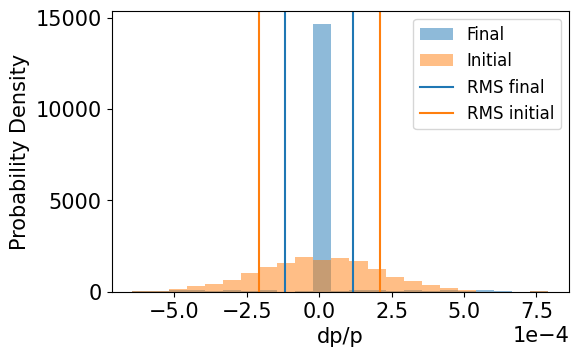

In [95]:
ion=calcium

loaded_data = np.load(f'results/{ion.name}.npz')

delta = loaded_data['delta']    # shape: (n_time, n_particles)
zeta = loaded_data['zeta']
state = loaded_data['state']
x = loaded_data['x'] 
time = loaded_data['time']
s_per_turn = loaded_data['s_per_turn']
px = loaded_data['px']
action_x = loaded_data['action_x']
action_y = loaded_data['action_y']
emittance_x = loaded_data['emittance_x']


delta_final=delta[-1]
delta_init=delta[0]
rms_final=np.std(delta_final)
rms_init=np.std(delta_init)

nbins=freedman_diaconis_bins(delta_init)
bins = np.linspace(min(delta_init), max(delta_init), nbins)

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=15)    # fontsize of the axes title
plt.rc('axes', labelsize=15)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)   # fontsize of the tick labels
plt.rc('ytick', labelsize=15)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

# Plot the histograms for visualization
fig=plt.figure()
plt.hist(delta_final, bins=bins, alpha=0.5, color='C0' ,label='Final', density=True)
plt.hist(delta_init, bins=bins, alpha=0.5, color='C1' ,label='Initial', density=True)
plt.axvline(rms_final,color='C0',label='RMS final')
plt.axvline(-rms_final,color='C0')
plt.axvline(rms_init,color='C1',label='RMS initial')
plt.axvline(-rms_init,color='C1')
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.legend()

image_name = 'calcium_dist_no_ibs.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'calcium_dist_no_ibs.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)


plt.show()

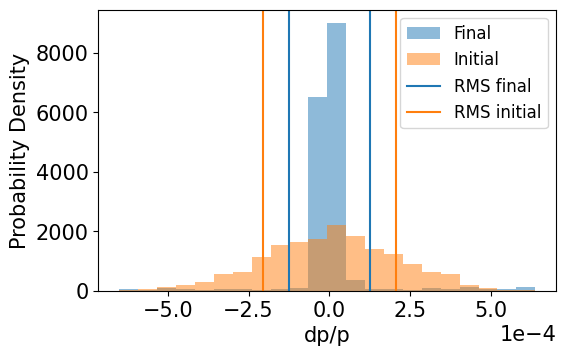

In [96]:
IBS_results = np.load(f'results/IBS/{ion.name}.npz')

delta_IBS = IBS_results['delta']
zeta_IBS = IBS_results['zeta']
emittance_x_IBS = IBS_results['emittance_x']
time_IBS = IBS_results['time']
rms_dp_p_IBS = np.std(delta_IBS, axis=1)

sigma_z=np.std(zeta_IBS[-1])

delta_final=delta_IBS[-1]
delta_init=delta_IBS[0]
rms_final=np.std(delta_final)
rms_init=np.std(delta_init)

nbins=freedman_diaconis_bins(delta_init)
bins = np.linspace(min(delta_init), max(delta_init), nbins)

# Plot the histograms for visualization
plt.figure()
plt.hist(delta_final, bins=bins, alpha=0.5, color='C0' ,label='Final', density=True)
plt.hist(delta_init, bins=bins, alpha=0.5, color='C1' ,label='Initial', density=True)
plt.axvline(rms_final,color='C0',label='RMS final')
plt.axvline(-rms_final,color='C0')
plt.axvline(rms_init,color='C1',label='RMS initial')
plt.axvline(-rms_init,color='C1')
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.legend()

image_name = 'calcium_dist_xsuite_ibs.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'calcium_dist_xsuite_ibs.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

show IBS growth rate

In [97]:
sigma_z

np.float64(0.05173679009080023)

In [98]:
# sig_delta_list = np.linspace(0.25e-4, 1.5e-4, 50)

# growth_rates_2d_x = np.zeros((len(sig_delta_list), 1))
# growth_rates_2d_y = np.zeros((len(sig_delta_list), 1))
# growth_rates_2d_z = np.zeros((len(sig_delta_list), 1))

# ion_example=calcium

# with open('sps.json', 'r') as f:
#     line = xt.Line.from_dict(json.load(f))  
# particle_ref0=line.particle_ref

# line.discard_tracker()
# q0 = ion_example.q0
# mass0 = ion_example.mass0
# beta0 = ion_example.beta_rel
# gamma0 = ion_example.gamma_rel
# # gamma = particle_ref.gamma0
# # beta= particle_ref.beta0
# sigma_z=ion_example.bunch_length
# p0c = mass0*gamma0*beta0 #eV/c
# bunch_intensity = ion_example.bunch_intensity
# particle_ref = xp.Particles(p0c=p0c, mass0=mass0, q0=q0)

# line.particle_ref=particle_ref
# line.build_tracker()
# twiss = line.twiss()

# injection_nemitt=0.4*1e-6
# sigma_z=np.std(zeta_IBS[-1]) # 0.0517

# bm_growth_rates = twiss.get_ibs_growth_rates(
#         formalism="bjorken-mtingwa", 
#         total_beam_intensity=bunch_intensity,
#         nemitt_x=injection_nemitt,
#         nemitt_y=injection_nemitt,
#         sigma_delta=0.75*1e-4,
#         bunch_length=sigma_z,
#         bunched=True,
#         )

# tz1=bm_growth_rates.Tz


# bm_growth_rates = twiss.get_ibs_growth_rates(
#         formalism="bjorken-mtingwa", 
#         total_beam_intensity=0.859*bunch_intensity,
#         nemitt_x=injection_nemitt,
#         nemitt_y=injection_nemitt,
#         sigma_delta=0.75*1e-4,
#         bunch_length=sigma_z,
#         bunched=True,
#         )

# tz2=bm_growth_rates.Tz

# for k, sig_delta_loop in enumerate(sig_delta_list):

#     print(f'{k}/{len(sig_delta_list)}')

#     bm_growth_rates = twiss.get_ibs_growth_rates(
#             formalism="bjorken-mtingwa", 
#             total_beam_intensity=bunch_intensity,
#             nemitt_x=injection_nemitt,
#             nemitt_y=injection_nemitt,
#             sigma_delta=sig_delta_loop,
#             bunch_length=sigma_z,
#             bunched=True,
#             )

#     growth_rates_2d_x[k, 0] = bm_growth_rates.Tx
#     growth_rates_2d_y[k, 0] = bm_growth_rates.Ty
#     growth_rates_2d_z[k, 0] = bm_growth_rates.Tz





In [99]:
# print('tz1',tz1)
# print('tz2',tz2)

In [100]:
# measured_rms=1.25*1e-4
# core_width_val=4.2*1e-5


# plt.figure()
# plt.plot(sig_delta_list, growth_rates_2d_z[:, 0], label=r'$T_z$')
# #plt.title('Tz Growth Rates')
# plt.xlabel('RMS dp/p')
# plt.ylabel('Longitudinal growth rate')
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# # plt.axhline(-growth_rate_xenon,color='red',label='Laser cooler growth rate')
# plt.axvline(measured_rms,label='Total RMS dp/p',color='C1')
# plt.axvline(core_width_val,label='Core RMS dp/p',color='C2')
# plt.legend()
# plt.tight_layout()


# image_name = 'calcium_ibs_exponential.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'calcium_ibs_exponential.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)

# plt.show()    

In [101]:


# plt.figure(figsize=(10,10))
# plt.subplot(3, 1, 1)
# plt.plot(sig_delta_list, growth_rates_2d_x[:, 0], label='Tx')
# plt.title('Tx Growth Rates')
# plt.xlabel('RMS dp/p')
# plt.ylabel('Growth Rate')
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# # plt.axhline(-growth_rate_xenon,color='red',label='Cooler growth rate')
# plt.axvline(measured_rms,label='RMS dp_p',color='C1')
# plt.axvline(core_width_val,label='Core width',color='C2')
# plt.legend()

# plt.subplot(3, 1, 2)
# plt.plot(sig_delta_list, growth_rates_2d_y[:, 0], label='Ty')
# plt.title('Ty Growth Rates')
# plt.xlabel('RMS dp/p')
# plt.ylabel('Growth Rate')
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# # plt.axhline(-growth_rate_xenon,color='red',label='Cooler growth rate')
# plt.axvline(measured_rms,label='RMS dp_p',color='C1')
# plt.axvline(core_width_val,label='Core width',color='C2')
# plt.legend()

# plt.subplot(3, 1, 3)
# plt.plot(sig_delta_list, growth_rates_2d_z[:, 0], label='Tz')
# plt.title('Tz Growth Rates')
# plt.xlabel('RMS dp/p')
# plt.ylabel('Growth Rate')
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# # plt.axhline(-growth_rate_xenon,color='red',label='Laser cooler growth rate')
# plt.axvline(measured_rms,label='RMS dp_p',color='C1')
# plt.axvline(core_width_val,label='Core width',color='C2')
# plt.legend()

# plt.tight_layout()
# plt.show()




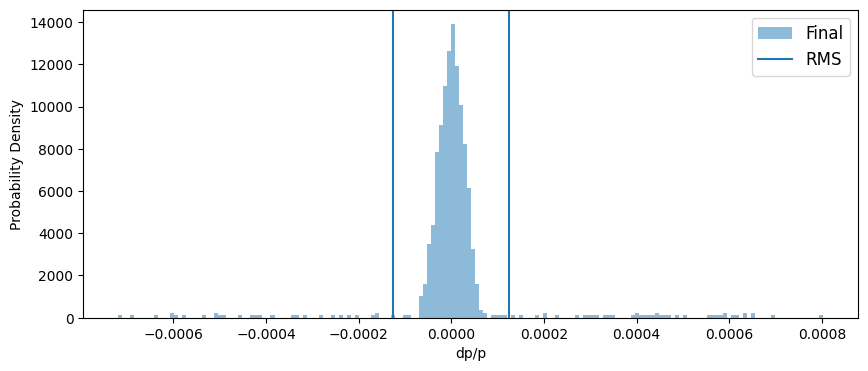

In [102]:
ion=calcium

IBS_results = np.load(f'results/IBS/{ion.name}.npz')

delta_IBS = IBS_results['delta']
zeta_IBS = IBS_results['zeta']
emittance_x_IBS = IBS_results['emittance_x']
time_IBS = IBS_results['time']
rms_dp_p_IBS = np.std(delta_IBS, axis=1)

sigma_z=np.std(zeta_IBS[-1])

delta_final=delta_IBS[-1]
rms_final=np.std(delta_final)


nbins=freedman_diaconis_bins(delta_final)
bins = np.linspace(min(delta_final), max(delta_final), nbins)

# Plot the histograms for visualization
plt.figure(figsize=(10, 4))
plt.hist(delta_final, bins=bins, alpha=0.5, color='C0' ,label='Final', density=True)
plt.axvline(rms_final,color='C0',label='RMS')
plt.axvline(-rms_final,color='C0')
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()
#plt.title('Histogram of Data')
plt.show()

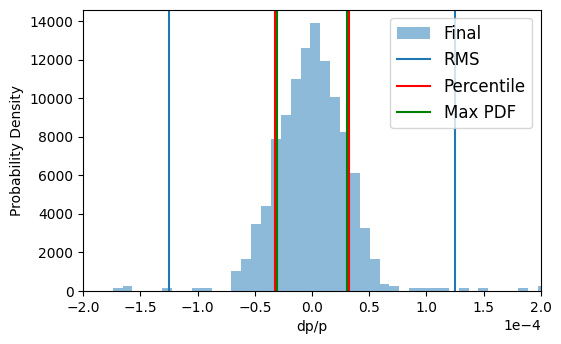

In [103]:
ion=calcium

IBS_results = np.load(f'results/IBS/{ion.name}.npz')

delta_IBS = IBS_results['delta']
zeta_IBS = IBS_results['zeta']
emittance_x_IBS = IBS_results['emittance_x']
time_IBS = IBS_results['time']
rms_dp_p_IBS = np.std(delta_IBS, axis=1)

sigma_z=np.std(zeta_IBS[-1])

delta_final=delta_IBS[-1]
rms_final=np.std(delta_final)

# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_final, [15, 85])
core = delta_final[(delta_final >= p20) & (delta_final <= p80)]
core_width=(p80-p20)/2
# Set up histogram bins.


nbins=freedman_diaconis_bins(delta_final)
bins = np.linspace(min(delta_final), max(delta_final), nbins)

counts, bin_edges = np.histogram(delta_final, bins=100, density=True)
# Calculate bin centers.
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Find the maximum PDF value and corresponding x-value.
max_pdf = counts.max()
# Compute sigma from the formula σ = 1 / (sqrt(2π) * f_max)
sigma = 1.0 / (np.sqrt(2.0 * np.pi) * max_pdf)

# Plot the histograms for visualization
plt.figure()
plt.hist(delta_final, bins=bins, alpha=0.5, color='C0' ,label='Final', density=True)
#plt.hist(core_threshhold, bins=bins, alpha=0.5, color='C1' ,label='Core AAD', density=True)
plt.axvline(rms_final,color='C0',label='RMS')
plt.axvline(-rms_final,color='C0')
plt.axvline(-core_width,color='red',label='Percentile')
plt.axvline(core_width,color='red')
plt.axvline(-sigma,color='green',label=r'Max PDF')
plt.axvline(sigma,color='green')
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()
plt.xlim(-2*1e-4,2e-4)
#plt.title('Histogram of Data')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

image_name = 'ibs_metrics.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'ibs_metrics.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)


plt.show()

show aad algorithm

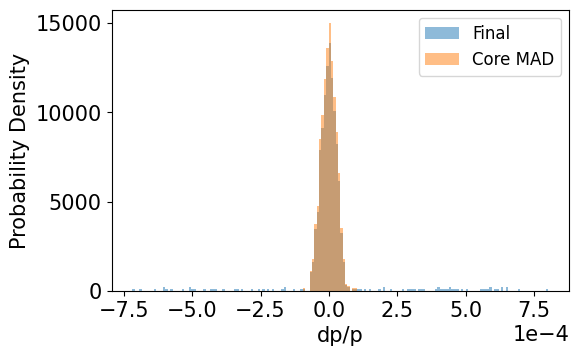

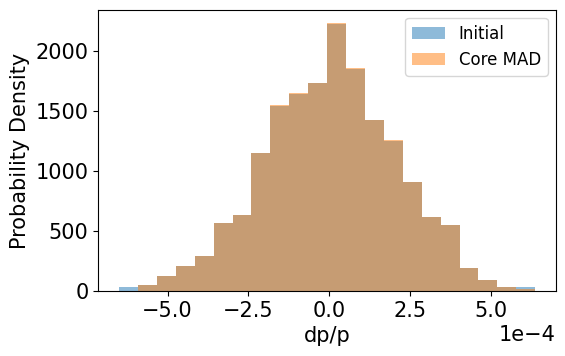

In [104]:
core_threshhold=extract_core_mad_fast(delta_final, scale=3.0)
core_threshhold_std=np.std(core_threshhold)

plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=15)    # fontsize of the axes title
plt.rc('axes', labelsize=15)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)   # fontsize of the tick labels
plt.rc('ytick', labelsize=15)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

nbins=freedman_diaconis_bins(delta_final)
bins = np.linspace(min(delta_final), max(delta_final), nbins)

plt.figure()
plt.hist(delta_final, bins=bins, alpha=0.5, color='C0' ,label='Final', density=True)
plt.hist(core_threshhold, bins=bins, alpha=0.5, color='C1' ,label='Core MAD', density=True)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

image_name = 'core_mad_final.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'core_mad_final.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

core_threshhold0=extract_core_mad_fast(delta_IBS[0], scale=3.0)
core_threshhold_std0=np.std(core_threshhold0)

nbins=freedman_diaconis_bins(delta_IBS[0])
bins = np.linspace(min(delta_IBS[0]), max(delta_IBS[0]), nbins)

plt.figure()
plt.hist(delta_IBS[0], bins=bins, alpha=0.5, color='C0' ,label='Initial', density=True)
plt.hist(core_threshhold0, bins=bins, alpha=0.5, color='C1' ,label='Core MAD', density=True)
plt.xlabel('dp/p')
plt.ylabel('Probability Density')
plt.legend()

#plt.title('Histogram of Data')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
image_name = 'core_mad_init.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'core_mad_init.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

In [105]:
np.argmin((time_IBS)-20.0)

np.int64(0)

In [106]:
def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

def plot_quiver(emittance, rms_dp_p, time, color, label):
    num_segments = 20
    step_size = len(time) // num_segments

    for j in range(num_segments):
        start_idx = j * step_size
        end_idx = min((j + 1) * step_size, len(time) - 1)
        
        start_x = emittance[start_idx]
        end_x = emittance[end_idx]
        
        start_y = rms_dp_p[start_idx]
        end_y = rms_dp_p[end_idx]

        label_str = label if j == 0 else None  
        
        arrow = plt.quiver(start_x, start_y, end_x - start_x, end_y - start_y, scale=1,
                            scale_units='xy', angles='xy', color=color, width=0.003,label=label_str)
        
        time_annotation_x = end_x
        time_annotation_y = end_y
        if j == num_segments - 1:
            time_annotation_text = f"{time[end_idx]:.1f}s"
            time_annotation_y = 0.98 * time_annotation_y
        else:
            time_annotation_text = f"{time[end_idx]:.1f}s"
        #plt.text(time_annotation_x, time_annotation_y, time_annotation_text, color='black', fontsize=10, ha='right', va='bottom')

0it [00:00, ?it/s]

1it [00:01,  1.94s/it]


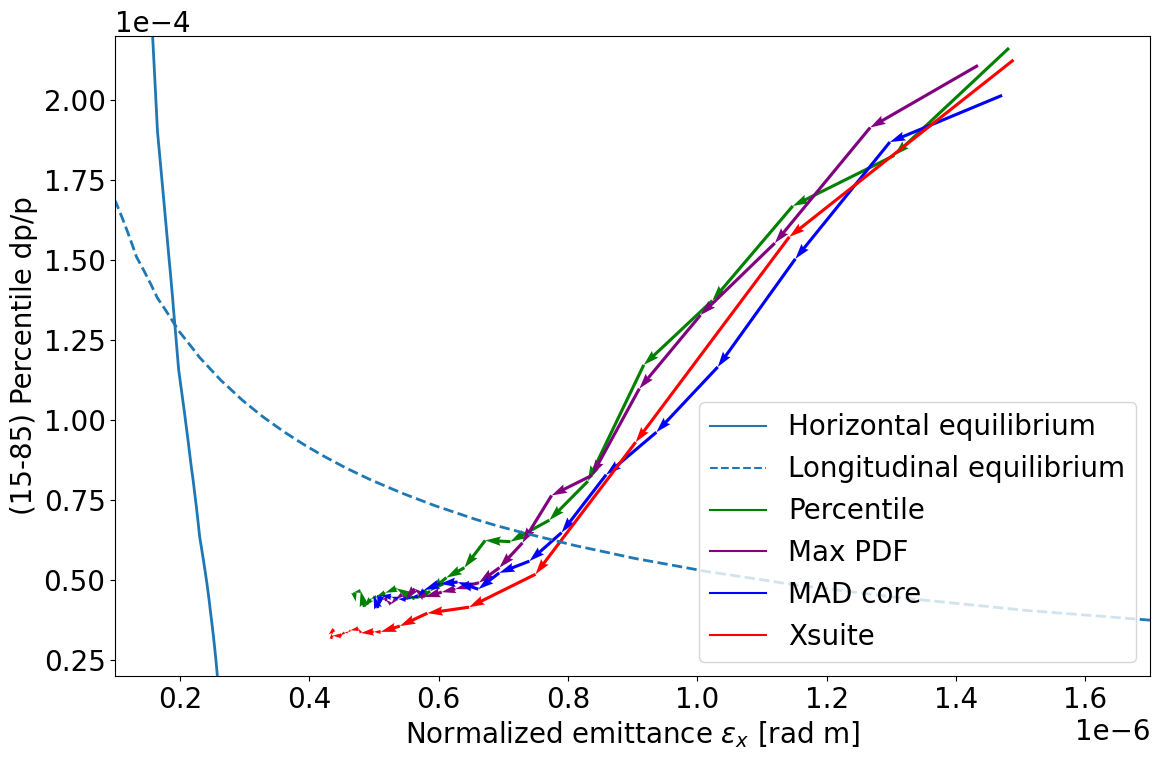

In [107]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})

plt.figure(figsize=(12, 8))

# plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    
 
    data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_old_ibs = data_old_ibs['delta']
    emittance_x_old_ibs = data_old_ibs['emittance_x']
    time_old_ibs = data_old_ibs['time']
    rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    #sigma_list_old_ibs=gauss_sigma(data_old_ibs)    
    core_width_old_ibs = core_width(data_old_ibs)

    mask = time_old_ibs <= 20

    # Apply the mask to slice the arrays.
    delta_old_ibs = delta_old_ibs[mask]
    emittance_x_old_ibs = emittance_x_old_ibs[mask]
    time_old_ibs = time_old_ibs[mask]
    core_width_old_ibs=np.array(core_width_old_ibs)[mask]

    data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

    delta_full_ibs = data_full_ibs['delta']
    emittance_x_full_ibs = data_full_ibs['emittance_x']
    time_full_ibs = data_full_ibs['time']
    rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
      

    data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

    delta_no_ibs = data_no_ibs['delta']
    emittance_x_no_ibs = data_no_ibs['emittance_x']
    time_no_ibs = data_no_ibs['time']
    rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    

    # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    # delta_10_90 = data_10_90['delta']
    # emittance_x_10_90 = data_10_90['emittance_x']
    # time_10_90 = data_10_90['time']
    # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    # sigma_list_10_90=gauss_sigma(data_10_90)

    

    data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    delta_10_90 = data_10_90['delta']
    emittance_x_10_90 = data_10_90['emittance_x']
    
    time_10_90 = data_10_90['time']
    rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    

    data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

    delta_20_80 = data_20_80['delta']
    emittance_x_20_80 = data_20_80['emittance_x']
    time_20_80 = data_20_80['time']
    rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    

    data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

    delta_30_70 = data_30_70['delta']
    emittance_x_30_70 = data_30_70['emittance_x']
    time_30_70 = data_30_70['time']
    rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    
    data_perc = np.load(f'results/IBS_custom/{ion_loop.name}_percentile_sigma.npz')

    delta_perc = data_perc['delta']
    emittance_x_perc = data_perc['emittance_x']
    time_perc = data_perc['time']
    rms_dp_p_perc = np.std(delta_perc, axis=1)    
    core_width_perc=core_width(data_perc)

    data_peak = np.load(f'results/IBS_custom/{ion_loop.name}_peak_davide.npz')
    delta_peak = data_peak['delta']
    zeta_peak = data_peak['zeta']
    emittance_x_peak = data_peak['emittance_x']
    time_peak = data_peak['time']
    rms_dp_p_peak = np.std(delta_peak, axis=1)    
    core_width_peak=core_width(data_peak)

    data_peter = np.load(f'results/IBS_custom/{ion_loop.name}_core_peter.npz')
    delta_peter = data_peter['delta']
    zeta_peter = data_peter['zeta']
    emittance_x_peter = data_peter['emittance_x']
    time_peter = data_peter['time']
    rms_dp_p_peter = np.std(delta_peter, axis=1)    
    core_width_peter=core_width(data_peter)


    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Percentile') 
plot_quiver(emittance_x_peak, core_width_peak, time_peak, 'purple', label='Max PDF') 
plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'blue', label='MAD core') 
plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'red', label='Xsuite') 

###############################################################################################################
data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
#max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# max_growth_rate=growth_rates_2d_x
sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']
total_intensity = data['total_intensity']

loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
#longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
laser_x_list = loaded_data['laser_x_list']

min_transverse_index = np.argmin(transverse_growth_rate_list)
min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

laser_position_index = 74
laser_position_index = min_transverse_index
laser_offset = laser_x_list[laser_position_index]
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
threshold_transverse = -min(transverse_growth_rate_list)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
            colors=cycle[0], linewidths=2)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
            colors=cycle[0], linestyles='--', linewidths=2)   

# injection_nemitt =1.5*1e-6
# injection_dp_p = 2e-4

# plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
# plt.text(1.1*injection_nemitt, 0.93*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right') 

# plt.xlim([0, 1.6*1e-6])
# plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]')
plt.ylabel('RMS dp/p')
plt.ylabel('(15-85) Percentile dp/p')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.legend(handles=[
    Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
    
    Line2D([0], [0], linestyle='-', color='green', label='Percentile'),
    Line2D([0], [0], linestyle='-', color='purple', label='Max PDF'),
    Line2D([0], [0], linestyle='-', color='blue', label='MAD core'),
    Line2D([0], [0], linestyle='-', color='red', label='Xsuite'), 
], loc='lower right')


#plt.legend(loc='upper left')

plt.tight_layout()
# Save image
image_name = 'ibs_metrics_tracking.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'ibs_metrics_tracking.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

plt.rcParams["figure.figsize"] = [fig_width, fig_height]

plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

In [108]:
core_width_peter[-1]/core_width_old_ibs[-1]

np.float64(1.3922319833059242)

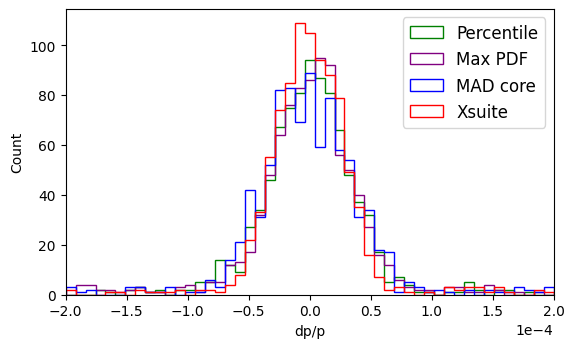

In [109]:
at_turn_idx=-1
nbins=freedman_diaconis_bins(delta_old_ibs)
bins = np.linspace(-2e-4, 2e-4, 50)
plt.figure()
plt.hist(delta_perc[at_turn_idx],bins=bins,histtype='step', color='green', label='Percentile',density=False) 
plt.hist(delta_peak[at_turn_idx],bins=bins,histtype='step', color='purple', label='Max PDF',density=False) 
plt.hist(delta_peter[at_turn_idx],bins=bins,histtype='step', color='blue', label='MAD core',density=False) 
plt.hist(delta_old_ibs[at_turn_idx],bins=bins,histtype='step', color='red', label='Xsuite',density=False)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0)) 
plt.xlabel('dp/p')
plt.ylabel('Count')
plt.legend()
plt.xlim(-2e-4,2e-4)
plt.tight_layout()

image_name = 'ibs_metrics_histogram.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'ibs_metrics_histogram.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

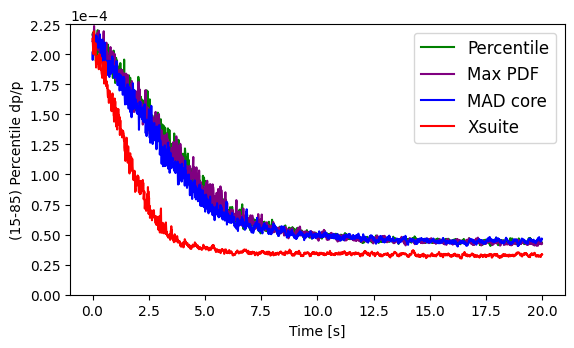

In [110]:
plt.figure()
plt.plot(time_perc,core_width_perc, color='green', label='Percentile') 
plt.plot(time_peak,core_width_peak, color='purple', label='Max PDF') 
plt.plot(time_peter,core_width_peter, color='blue', label='MAD core') 
plt.plot(time_old_ibs,core_width_old_ibs, color='red', label='Xsuite')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0)) 
plt.xlabel('Time [s]')
plt.ylabel('(15-85) Percentile dp/p')
plt.legend()
plt.ylim(0,2.25*1e-4)
plt.tight_layout()

image_name = 'ibs_metrics_decay_rates.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'ibs_metrics_decay_rates.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)

plt.show()

with changing cooling rate

0it [00:00, ?it/s]

1it [00:02,  2.06s/it]


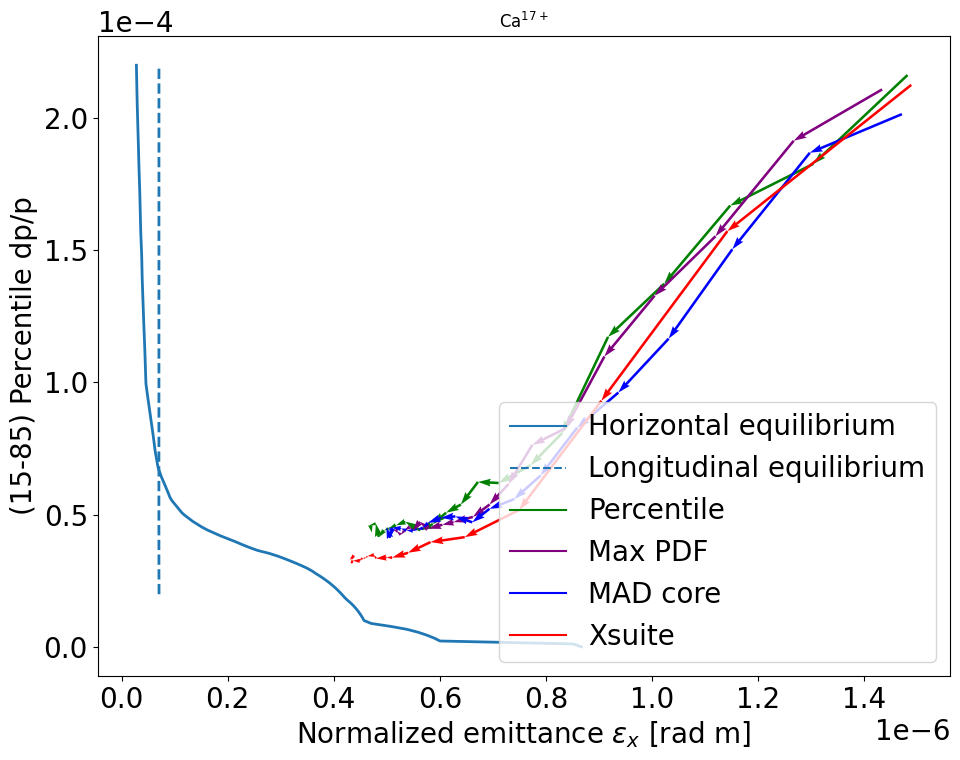

In [111]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq


def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})

fig, ax = plt.subplots(figsize=(10, 8))

# plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    
 
    data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_old_ibs = data_old_ibs['delta']
    emittance_x_old_ibs = data_old_ibs['emittance_x']
    time_old_ibs = data_old_ibs['time']
    rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    #sigma_list_old_ibs=gauss_sigma(data_old_ibs)    
    core_width_old_ibs = core_width(data_old_ibs)

    mask = time_old_ibs <= 20

    # Apply the mask to slice the arrays.
    delta_old_ibs = delta_old_ibs[mask]
    emittance_x_old_ibs = emittance_x_old_ibs[mask]
    time_old_ibs = time_old_ibs[mask]
    core_width_old_ibs=np.array(core_width_old_ibs)[mask]

    data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

    delta_full_ibs = data_full_ibs['delta']
    emittance_x_full_ibs = data_full_ibs['emittance_x']
    time_full_ibs = data_full_ibs['time']
    rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
      

    data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

    delta_no_ibs = data_no_ibs['delta']
    emittance_x_no_ibs = data_no_ibs['emittance_x']
    time_no_ibs = data_no_ibs['time']
    rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    

    # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    # delta_10_90 = data_10_90['delta']
    # emittance_x_10_90 = data_10_90['emittance_x']
    # time_10_90 = data_10_90['time']
    # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    # sigma_list_10_90=gauss_sigma(data_10_90)

    

    data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    delta_10_90 = data_10_90['delta']
    emittance_x_10_90 = data_10_90['emittance_x']
    
    time_10_90 = data_10_90['time']
    rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    

    data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

    delta_20_80 = data_20_80['delta']
    emittance_x_20_80 = data_20_80['emittance_x']
    time_20_80 = data_20_80['time']
    rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    

    data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

    delta_30_70 = data_30_70['delta']
    emittance_x_30_70 = data_30_70['emittance_x']
    time_30_70 = data_30_70['time']
    rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    
    data_perc = np.load(f'results/IBS_custom/{ion_loop.name}_percentile_sigma.npz')

    delta_perc = data_perc['delta']
    emittance_x_perc = data_perc['emittance_x']
    time_perc = data_perc['time']
    rms_dp_p_perc = np.std(delta_perc, axis=1)    
    core_width_perc=core_width(data_perc)

    data_peak = np.load(f'results/IBS_custom/{ion_loop.name}_peak_davide.npz')
    delta_peak = data_peak['delta']
    zeta_peak = data_peak['zeta']
    emittance_x_peak = data_peak['emittance_x']
    time_peak = data_peak['time']
    rms_dp_p_peak = np.std(delta_peak, axis=1)    
    core_width_peak=core_width(data_peak)

    data_peter = np.load(f'results/IBS_custom/{ion_loop.name}_core_peter.npz')
    delta_peter = data_peter['delta']
    zeta_peter = data_peter['zeta']
    emittance_x_peter = data_peter['emittance_x']
    time_peter = data_peter['time']
    rms_dp_p_peter = np.std(delta_peter, axis=1)    
    core_width_peter=core_width(data_peter)


    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Percentile') 
plot_quiver(emittance_x_peak, core_width_peak, time_peak, 'purple', label='Max PDF') 
plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'blue', label='MAD core') 
plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'red', label='Xsuite') 

###############################################################################################################
data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
#max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# max_growth_rate=growth_rates_2d_x
sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']
total_intensity = data['total_intensity']

loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
#longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
laser_x_list = loaded_data['laser_x_list']

min_transverse_index = np.argmin(transverse_growth_rate_list)
min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

laser_position_index = 74
laser_position_index = min_transverse_index
laser_offset = laser_x_list[laser_position_index]
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
threshold_transverse = -min(transverse_growth_rate_list)

data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long  = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool  = data_cool['n_emitt_list']
sd_cool    = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs   = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
ibs_long   = data_ibs['growth_rates_2d_z']
ibs_horiz  = data_ibs['growth_rates_2d_x']
n_em_ibs   = data_ibs['n_emitt_list']
sd_ibs     = data_ibs['sig_delta_list']

ata_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long  = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool  = data_cool['n_emitt_list']
sd_cool    = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs   = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
ibs_long   = data_ibs['growth_rates_2d_z']
ibs_horiz  = data_ibs['growth_rates_2d_x']
n_em_ibs   = data_ibs['n_emitt_list']
sd_ibs     = data_ibs['sig_delta_list']

# --------------------------------------------------
# 3) Build the OVERLAP grid (only where both data sets exist)
# --------------------------------------------------
n_min = max(n_em_cool[0],  n_em_ibs[0])
n_max = min(n_em_cool[-1], n_em_ibs[-1])
s_min = max(sd_cool[0],    sd_ibs[0])
s_max = min(sd_cool[-1],   sd_ibs[-1])

n_pts = 200
n_common = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, n_pts)

# --------------------------------------------------
# 4) Create interpolators (no extrapolation: out‐of‐bounds → NaN)
# --------------------------------------------------
interp_h_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_horiz,
    bounds_error=False, fill_value=None
)
interp_h_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_horiz,
    bounds_error=False, fill_value=None
)
interp_l_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_long,
    bounds_error=False, fill_value=None
)
interp_l_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_long,
    bounds_error=False, fill_value=None
)

# --------------------------------------------------
# 5) Define net‐rate functions for root‐finding
# --------------------------------------------------
def net_h(eps, s):
    # horizontal net rate at (eps, s)
    return float(interp_h_c((s, eps))) + float(interp_h_i((s, eps)))

def net_l(eps, s):
    # longitudinal net rate at (eps, s)
    return float(interp_l_c((s, eps))) + float(interp_l_i((s, eps)))

# --------------------------------------------------
# 6) Find one zero‐crossing per delta (s_common) with brentq
# --------------------------------------------------
eq_h = np.full_like(s_common, np.nan)
eq_l = np.full_like(s_common, np.nan)

for i, s in enumerate(s_common):
    # bracket endpoints
    a, b = n_min, n_max

    # horizontal: try to find any root in [a, b]
    try:
        if np.sign(net_h(a, s)) != np.sign(net_h(b, s)):
            eq_h[i] = brentq(net_h, a, b, args=(s,))
    except (ValueError, RuntimeError):
        eq_h[i] = np.nan

    # longitudinal: try to find any root in [a, b]
    try:
        if np.sign(net_l(a, s)) != np.sign(net_l(b, s)):
            eq_l[i] = brentq(net_l, a, b, args=(s,))
    except (ValueError, RuntimeError):
        eq_l[i] = np.nan

# --------------------------------------------------
# 7) Plot everything
# --------------------------------------------------


# --- your quiver fields go here ---
# plot_quiver(emittance_x_lattice, core_width_lattice, time_lattice,
#             color='black', label='Lattice without IBS')
# plot_quiver(emittance_x_IBS,     core_width_IBS,     time_IBS,
#             color='C1',       label='With IBS')

# equilibrium curves:
ax.plot(eq_h, s_common,  '-',  color='C0', linewidth=2,
        label='Horizontal Equilibrium')
ax.plot(eq_l, s_common,  '--', color='C0', linewidth=2,
        label='Longitudinal Equilibrium')

# injection_nemitt =1.5*1e-6
# injection_dp_p = 2e-4

# plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
# plt.text(1.1*injection_nemitt, 0.93*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right') 

# plt.xlim([0, 1.6*1e-6])
# plt.ylim([0, 3*1e-4])
plt.title(f'{ion_loop.name}')
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]')
plt.ylabel('RMS dp/p')
plt.ylabel('(15-85) Percentile dp/p')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.legend(handles=[
    Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
    
    Line2D([0], [0], linestyle='-', color='green', label='Percentile'),
    Line2D([0], [0], linestyle='-', color='purple', label='Max PDF'),
    Line2D([0], [0], linestyle='-', color='blue', label='MAD core'),
    Line2D([0], [0], linestyle='-', color='red', label='Xsuite'), 
], loc='lower right')


#plt.legend(loc='upper left')

plt.tight_layout()
# Save image
# image_name = 'ibs_metrics_tracking.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'ibs_metrics_tracking.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

plt.rcParams["figure.figsize"] = [fig_width, fig_height]

plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

In [112]:
sd_cool[0]

np.float64(1e-10)

<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
/tmp/pkruyt/ipykernel_32332/1491716975.py:87: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Normalized emittance $\epsilon_x$ [rad m]')


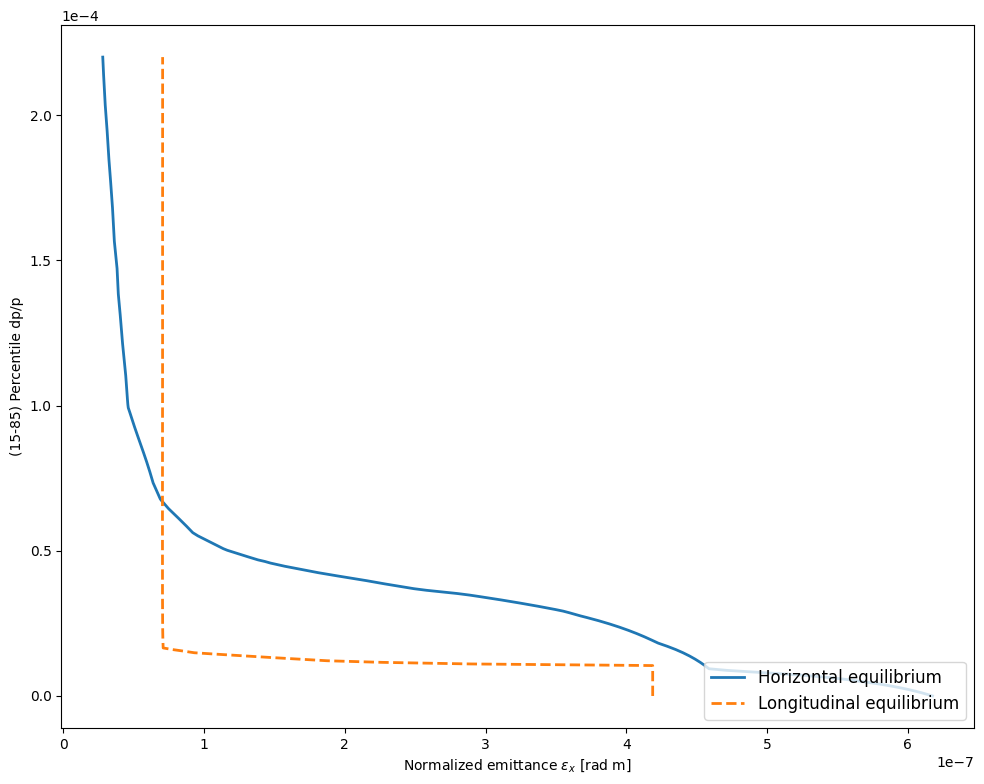

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# --- User's core_width and data-loading omitted for brevity ---
# Assume ion_loop.name is defined and core_width(data) is available.

# 1) Load cooling and IBS bunched data
data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool = data_cool['n_emitt_list']
sd_cool = data_cool['sig_delta_list']

data_ibs = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
ibs_long = data_ibs['growth_rates_2d_z']
ibs_horiz = data_ibs['growth_rates_2d_x']
n_em_ibs = data_ibs['n_emitt_list']
sd_ibs = data_ibs['sig_delta_list']

# 2) Build an extended Δp/p and ε_x domain
s_min = min(sd_cool[0], sd_ibs[0])
s_max = max(sd_cool[-1], sd_ibs[-1])
n_min = min(n_em_cool[0], n_em_ibs[0])
n_max = max(n_em_cool[-1], n_em_ibs[-1])

n_pts, s_pts = 400, 400
eps_scan = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, s_pts)

# 3) Create interpolators with zero extrapolation
def make_interp(x, y, values):
    return RegularGridInterpolator((x, y), values, bounds_error=False, fill_value=0.0)

interp_h_c = make_interp(sd_cool, n_em_cool, cool_horiz)
interp_h_i = make_interp(sd_ibs,   n_em_ibs,   ibs_horiz)
interp_l_c = make_interp(sd_cool, n_em_cool, cool_long)
interp_l_i = make_interp(sd_ibs,   n_em_ibs,   ibs_long)

# 4) Define net-rate functions
def net_h(eps, s): return float(interp_h_c((s, eps))) + float(interp_h_i((s, eps)))

def net_l(eps, s): return float(interp_l_c((s, eps))) + float(interp_l_i((s, eps)))

# 5) Find zero-crossings
eq_h = np.full_like(s_common, np.nan)
eq_l = np.full_like(s_common, np.nan)

for i, s in enumerate(s_common):
    # longitudinal roots
    vals_l = np.sign([net_l(eps, s) for eps in eps_scan])
    idx_l = np.where(vals_l[:-1] * vals_l[1:] < 0)[0]
    if idx_l.size:
        a, b = eps_scan[idx_l[0]], eps_scan[idx_l[0] + 1]
        try:
            eq_l[i] = brentq(lambda e: net_l(e, s), a, b)
        except Exception:
            pass

    # horizontal roots
    vals_h = np.sign([net_h(eps, s) for eps in eps_scan])
    idx_h = np.where(vals_h[:-1] * vals_h[1:] < 0)[0]
    if idx_h.size:
        a_h, b_h = eps_scan[idx_h[0]], eps_scan[idx_h[0] + 1]
        try:
            eq_h[i] = brentq(lambda e: net_h(e, s), a_h, b_h)
        except Exception:
            pass

# 5b) Fill NaNs to avoid truncation: extend first/last valid root
for arr in (eq_h, eq_l):
    valid = ~np.isnan(arr)
    if valid.any():
        first, last = arr[valid][0], arr[valid][-1]
        first_idx, last_idx = np.where(valid)[0][0], np.where(valid)[0][-1]
        arr[:first_idx] = first
        arr[last_idx + 1:] = last

# 6) Plot quiver and equilibrium curves
fig, ax = plt.subplots(figsize=(10, 8))
# [Insert your existing plot_quiver(...) calls here]

ax.plot(eq_h, s_common, '-', linewidth=2, label='Horizontal equilibrium')
ax.plot(eq_l, s_common, '--', linewidth=2, label='Longitudinal equilibrium')

ax.set_xlabel('Normalized emittance $\epsilon_x$ [rad m]')
ax.set_ylabel('(15-85) Percentile dp/p')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


<>:92: SyntaxWarning: invalid escape sequence '\e'
<>:92: SyntaxWarning: invalid escape sequence '\e'
/tmp/pkruyt/ipykernel_32332/3187876814.py:92: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Normalized emittance $\epsilon_x$ [rad·m]')


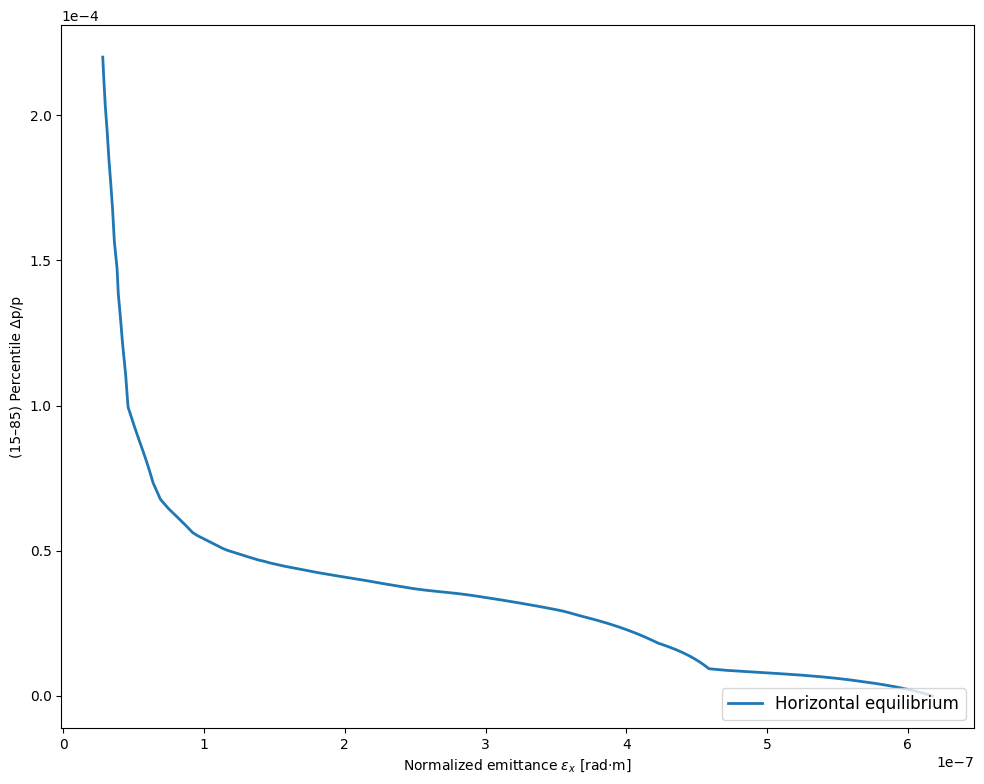

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# --- User's core_width and data-loading omitted for brevity ---
# Assume ion_loop.name is defined and core_width(data) is available.

# 1) Load cooling and IBS bunched data
data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool = data_cool['n_emitt_list']
sd_cool = data_cool['sig_delta_list']

data_ibs = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
ibs_long = data_ibs['growth_rates_2d_z']
ibs_horiz = data_ibs['growth_rates_2d_x']
n_em_ibs = data_ibs['n_emitt_list']
sd_ibs = data_ibs['sig_delta_list']

# 2) Build an extended Δp/p and ε_x domain (union grid)
s_min = min(sd_cool[0], sd_ibs[0])
s_max = max(sd_cool[-1], sd_ibs[-1])
n_min = min(n_em_cool[0], n_em_ibs[0])
n_max = max(n_em_cool[-1], n_em_ibs[-1])

n_pts, s_pts = 400, 400
eps_scan = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, s_pts)

# 3) Create interpolators with zero extrapolation
def make_interp(x, y, values):
    return RegularGridInterpolator((x, y), values,
                                   bounds_error=False,
                                   fill_value=0.0)

interp_h_c = make_interp(sd_cool, n_em_cool, cool_horiz)
interp_h_i = make_interp(sd_ibs,   n_em_ibs,   ibs_horiz)
interp_l_c = make_interp(sd_cool, n_em_cool, cool_long)
interp_l_i = make_interp(sd_ibs,   n_em_ibs,   ibs_long)

# 4) Define net‐rate functions
def net_h(eps, s):
    return float(interp_h_c((s, eps))) + float(interp_h_i((s, eps)))

def net_l(eps, s):
    return float(interp_l_c((s, eps))) + float(interp_l_i((s, eps)))

# 5) Find zero‐crossings for each Δp/p slice
eq_h = np.full_like(s_common, np.nan)
# eq_l = np.full_like(s_common, np.nan)  # no longer needed

for i, s in enumerate(s_common):
    # horizontal roots
    vals_h = np.sign([net_h(eps, s) for eps in eps_scan])
    idx_h = np.where(vals_h[:-1] * vals_h[1:] < 0)[0]
    if idx_h.size:
        a_h, b_h = eps_scan[idx_h[0]], eps_scan[idx_h[0] + 1]
        try:
            eq_h[i] = brentq(lambda e: net_h(e, s), a_h, b_h)
        except Exception:
            pass

    # # longitudinal roots (omitted)
    # vals_l = np.sign([net_l(eps, s) for eps in eps_scan])
    # idx_l = np.where(vals_l[:-1] * vals_l[1:] < 0)[0]
    # if idx_l.size:
    #     a, b = eps_scan[idx_l[0]], eps_scan[idx_l[0] + 1]
    #     try:
    #         eq_l[i] = brentq(lambda e: net_l(e, s), a, b)
    #     except Exception:
    #         pass

# 5b) Fill NaNs so that the horizontal curve spans entire range
valid_h = ~np.isnan(eq_h)
if valid_h.any():
    first_h, last_h = eq_h[valid_h][0], eq_h[valid_h][-1]
    first_idx_h, last_idx_h = np.where(valid_h)[0][0], np.where(valid_h)[0][-1]
    eq_h[:first_idx_h] = first_h
    eq_h[last_idx_h + 1:] = last_h

# 6) Plot quiver and horizontal equilibrium curve
fig, ax = plt.subplots(figsize=(10, 8))

# [Insert your existing plot_quiver(...) calls here to show the vector field]

ax.plot(eq_h, s_common,
        '-', linewidth=2,
        label='Horizontal equilibrium')

ax.set_xlabel('Normalized emittance $\epsilon_x$ [rad·m]')
ax.set_ylabel('(15–85) Percentile Δp/p')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


0it [00:00, ?it/s]

1it [00:01,  1.93s/it]
/tmp/pkruyt/ipykernel_32332/2542040904.py:192: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


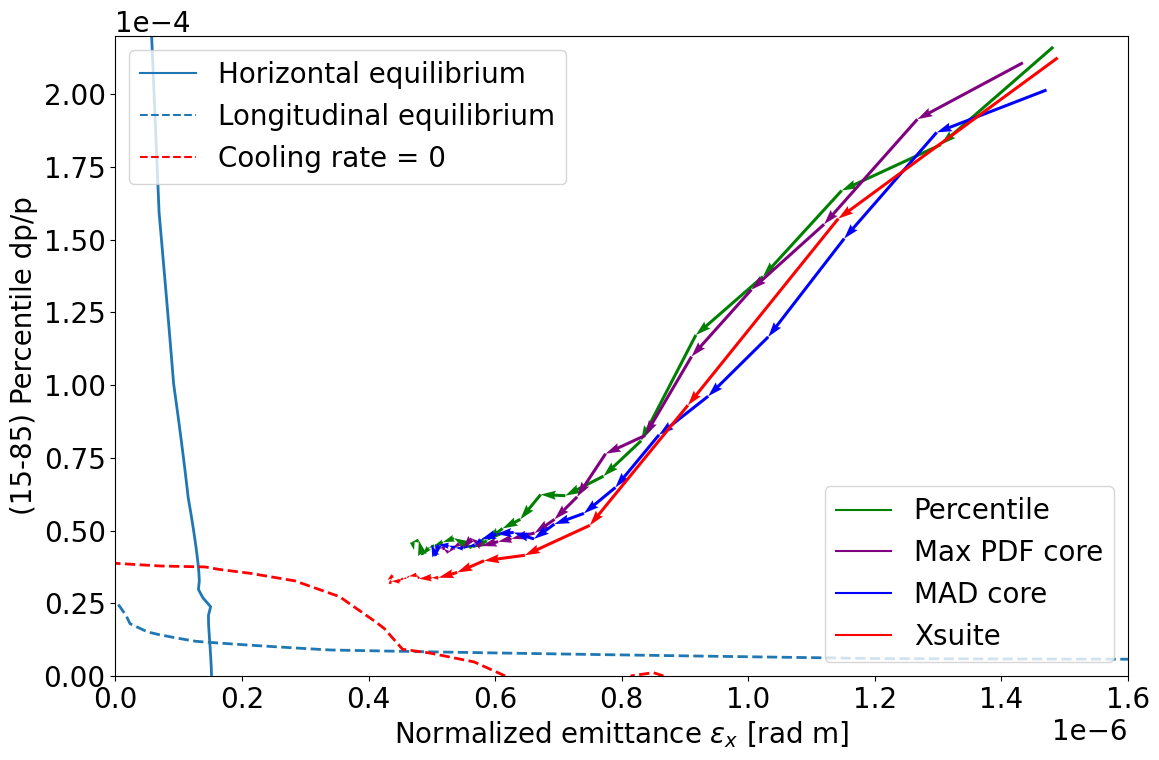

In [143]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})

fig, ax = plt.subplots(figsize=(12, 8))

# plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    
 
    data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_old_ibs = data_old_ibs['delta']
    emittance_x_old_ibs = data_old_ibs['emittance_x']
    time_old_ibs = data_old_ibs['time']
    rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    #sigma_list_old_ibs=gauss_sigma(data_old_ibs)    
    core_width_old_ibs = core_width(data_old_ibs)

    mask = time_old_ibs <= 20

    # Apply the mask to slice the arrays.
    delta_old_ibs = delta_old_ibs[mask]
    emittance_x_old_ibs = emittance_x_old_ibs[mask]
    time_old_ibs = time_old_ibs[mask]
    core_width_old_ibs=np.array(core_width_old_ibs)[mask]

    data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

    delta_full_ibs = data_full_ibs['delta']
    emittance_x_full_ibs = data_full_ibs['emittance_x']
    time_full_ibs = data_full_ibs['time']
    rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
      

    data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

    delta_no_ibs = data_no_ibs['delta']
    emittance_x_no_ibs = data_no_ibs['emittance_x']
    time_no_ibs = data_no_ibs['time']
    rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    

    # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    # delta_10_90 = data_10_90['delta']
    # emittance_x_10_90 = data_10_90['emittance_x']
    # time_10_90 = data_10_90['time']
    # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    # sigma_list_10_90=gauss_sigma(data_10_90)

    

    data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    delta_10_90 = data_10_90['delta']
    emittance_x_10_90 = data_10_90['emittance_x']
    
    time_10_90 = data_10_90['time']
    rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    

    data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

    delta_20_80 = data_20_80['delta']
    emittance_x_20_80 = data_20_80['emittance_x']
    time_20_80 = data_20_80['time']
    rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    

    data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

    delta_30_70 = data_30_70['delta']
    emittance_x_30_70 = data_30_70['emittance_x']
    time_30_70 = data_30_70['time']
    rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    
    data_perc = np.load(f'results/IBS_custom/{ion_loop.name}_percentile_sigma.npz')

    delta_perc = data_perc['delta']
    emittance_x_perc = data_perc['emittance_x']
    time_perc = data_perc['time']
    rms_dp_p_perc = np.std(delta_perc, axis=1)    
    core_width_perc=core_width(data_perc)

    data_peak = np.load(f'results/IBS_custom/{ion_loop.name}_peak_davide.npz')
    delta_peak = data_peak['delta']
    zeta_peak = data_peak['zeta']
    emittance_x_peak = data_peak['emittance_x']
    time_peak = data_peak['time']
    rms_dp_p_peak = np.std(delta_peak, axis=1)    
    core_width_peak=core_width(data_peak)

    data_peter = np.load(f'results/IBS_custom/{ion_loop.name}_core_peter.npz')
    delta_peter = data_peter['delta']
    zeta_peter = data_peter['zeta']
    emittance_x_peter = data_peter['emittance_x']
    time_peter = data_peter['time']
    rms_dp_p_peter = np.std(delta_peter, axis=1)    
    core_width_peter=core_width(data_peter)


    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Percentile') 
plot_quiver(emittance_x_peak, core_width_peak, time_peak, 'purple', label='Max PDF') 
plot_quiver(emittance_x_peter, core_width_peter, time_peter, 'blue', label='MAD core') 
plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'red', label='Xsuite') 

###############################################################################################################
data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

growth_rates_2d_x = data['growth_rates_2d_x']
growth_rates_2d_y = data['growth_rates_2d_y']
growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
#max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# max_growth_rate=growth_rates_2d_x
sig_delta_list = data['sig_delta_list']
n_emitt_list = data['n_emitt_list']
total_intensity = data['total_intensity']

loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
#longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
laser_x_list = loaded_data['laser_x_list']

min_transverse_index = np.argmin(transverse_growth_rate_list)
min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

laser_position_index = 74
laser_position_index = min_transverse_index
laser_offset = laser_x_list[laser_position_index]
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
#threshold_longitudinal = 0.029226287254179285
threshold_longitudinal = 1.643
#threshold_longitudinal=50*0.029226287254179285
threshold_transverse = -min(transverse_growth_rate_list)

threshold_transverse = 6.862e-02

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
            colors=cycle[0], linewidths=2)

plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
            colors=cycle[0], linestyles='--', linewidths=2)   

data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool = data_cool['n_emitt_list']
sd_cool = data_cool['sig_delta_list']

plt.contour(
        n_em_cool, sd_cool, cool_horiz,
        levels=[0],
        colors='red',
        linewidths=2,
        linestyles='--',
        label='Cooling rate = 0'
    )

# injection_nemitt =1.5*1e-6
# injection_dp_p = 2e-4

# plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
# plt.text(1.1*injection_nemitt, 0.93*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right') 

plt.xlim([0, 1.6*1e-6])
plt.ylim([0, 2.2*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]')
plt.ylabel('RMS dp/p')
plt.ylabel('(15-85) Percentile dp/p')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
#     Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
    
#     Line2D([0], [0], linestyle='-', color='green', label='Percentile'),
#     Line2D([0], [0], linestyle='-', color='purple', label='Max PDF'),
#     Line2D([0], [0], linestyle='-', color='blue', label='MAD core'),
#     Line2D([0], [0], linestyle='-', color='red', label='Xsuite'), 
# ], loc='lower right')

# ------------------------------------------------------------------
# Split legends
# ------------------------------------------------------------------
# Equilibria
eq_handles = [
    Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
    Line2D([0], [0], linestyle='--', color='red', label='Cooling rate = 0')
]
leg1 = ax.legend(handles=eq_handles, loc='upper left')
ax.add_artist(leg1)

# Curves
curve_handles = [
    Line2D([0], [0], linestyle='-', color='green', label='Percentile'),
    Line2D([0], [0], linestyle='-', color='purple', label='Max PDF core'),
    Line2D([0], [0], linestyle='-', color='blue', label='MAD core'),
    Line2D([0], [0], linestyle='-', color='red', label='Xsuite')
]
ax.legend(handles=curve_handles, loc='lower right')

plt.tight_layout()
# Save image
image_name = 'total_equilibria.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'total_equilibria.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

plt.rcParams["figure.figsize"] = [fig_width, fig_height]

plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

In [122]:
threshold_longitudinal

np.float64(0.029226287254179285)

In [ ]:
ion=lead

data=np.load(f'results/IBS/{ion.name}.npz')
delta = data['delta']
zeta=data['zeta']
state=data['state']
emittance_x = data['emittance_x']
time = data['time']
rms_dp_p = np.std(delta, axis=1)
emittance_x = emittance_x[:]
rms_dp_p = rms_dp_p[:]
num_particles=np.sum(state,axis=1)
index_closest_to_40 = np.argmin(np.abs(time - 40))



1it [00:02,  2.67s/it]


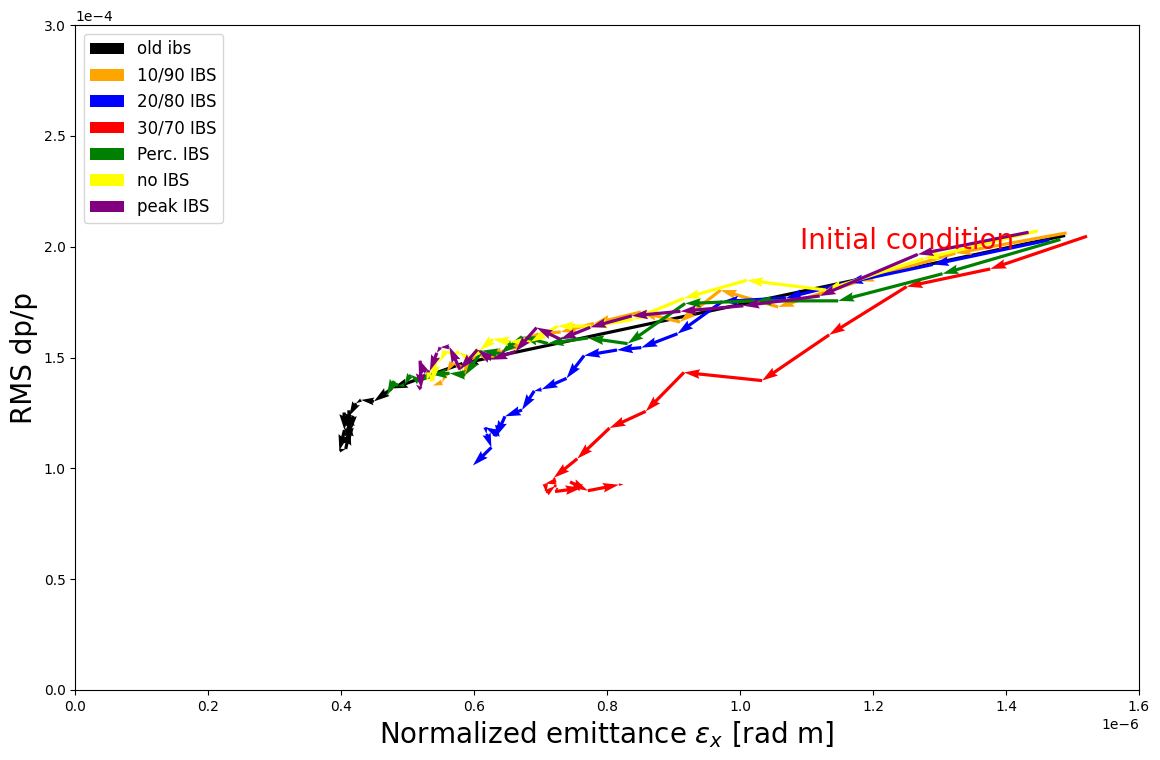

In [ ]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    
    data_custom = np.load(f'results/IBS_custom/{ion_loop.name}_new_kicks.npz')

    delta_custom = data_custom['delta']
    emittance_x_custom = data_custom['emittance_x']
    time_custom = data_custom['time']
    rms_dp_p_custom = np.std(delta_custom, axis=1)
    
    # data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    # delta_old_ibs = data_old_ibs['delta']
    # emittance_x_old_ibs = data_old_ibs['emittance_x']
    # time_old_ibs = data_old_ibs['time']
    # rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    # sigma_list_old_ibs=gauss_sigma(data_old_ibs)    

    data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_old_ibs = data_old_ibs['delta']
    emittance_x_old_ibs = data_old_ibs['emittance_x']
    time_old_ibs = data_old_ibs['time']
    rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
    
    core_width_old_ibs=core_width(data_old_ibs)

    data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

    delta_full_ibs = data_full_ibs['delta']
    emittance_x_full_ibs = data_full_ibs['emittance_x']
    time_full_ibs = data_full_ibs['time']
    rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
    
    data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

    delta_no_ibs = data_no_ibs['delta']
    emittance_x_no_ibs = data_no_ibs['emittance_x']
    time_no_ibs = data_no_ibs['time']
    rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    
    # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    # delta_10_90 = data_10_90['delta']
    # emittance_x_10_90 = data_10_90['emittance_x']
    # time_10_90 = data_10_90['time']
    # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    # sigma_list_10_90=gauss_sigma(data_10_90)
    
    data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

    delta_10_90 = data_10_90['delta']
    emittance_x_10_90 = data_10_90['emittance_x']
    time_10_90 = data_10_90['time']
    rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    core_width_10_90=core_width(data_10_90)

    data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

    delta_20_80 = data_20_80['delta']
    emittance_x_20_80 = data_20_80['emittance_x']
    time_20_80 = data_20_80['time']
    rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    core_width_20_80=core_width(data_20_80)

    data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

    delta_30_70 = data_30_70['delta']
    emittance_x_30_70 = data_30_70['emittance_x']
    time_30_70 = data_30_70['time']
    rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    core_width_30_70=core_width(data_30_70)

    data_perc = np.load(f'results/IBS_custom/{ion_loop.name}_percentile_sigma.npz')

    delta_perc = data_perc['delta']
    emittance_x_perc = data_perc['emittance_x']
    time_perc = data_perc['time']
    rms_dp_p_perc = np.std(delta_perc, axis=1)
    core_width_perc=core_width(data_perc)

    data_peak = np.load(f'results/IBS_custom/{ion_loop.name}_peak_davide.npz')
    delta_peak = data_peak['delta']
    zeta_peak = data_peak['zeta']
    emittance_x_peak = data_peak['emittance_x']
    time_peak = data_peak['time']
    rms_dp_p_peak = np.std(delta_peak, axis=1)
    core_width_peak=core_width(data_peak)


    emittance_x_values = emittance_x_custom[:]
    rms_dp_p_values = rms_dp_p_custom[:]   
    
# plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')
plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 

plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 

plot_quiver(emittance_x_perc, rms_dp_p_perc, time_perc, 'green', label='Perc. IBS') 
plot_quiver(emittance_x_no_ibs, rms_dp_p_no_ibs, time_10_90, 'yellow', label='no IBS') 

plot_quiver(emittance_x_peak, rms_dp_p_peak, time_10_90, 'purple', label='peak IBS') 

injection_nemitt = emittance_x[0]
injection_dp_p = rms_dp_p[0]

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([0, 1.6*1e-6])
plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

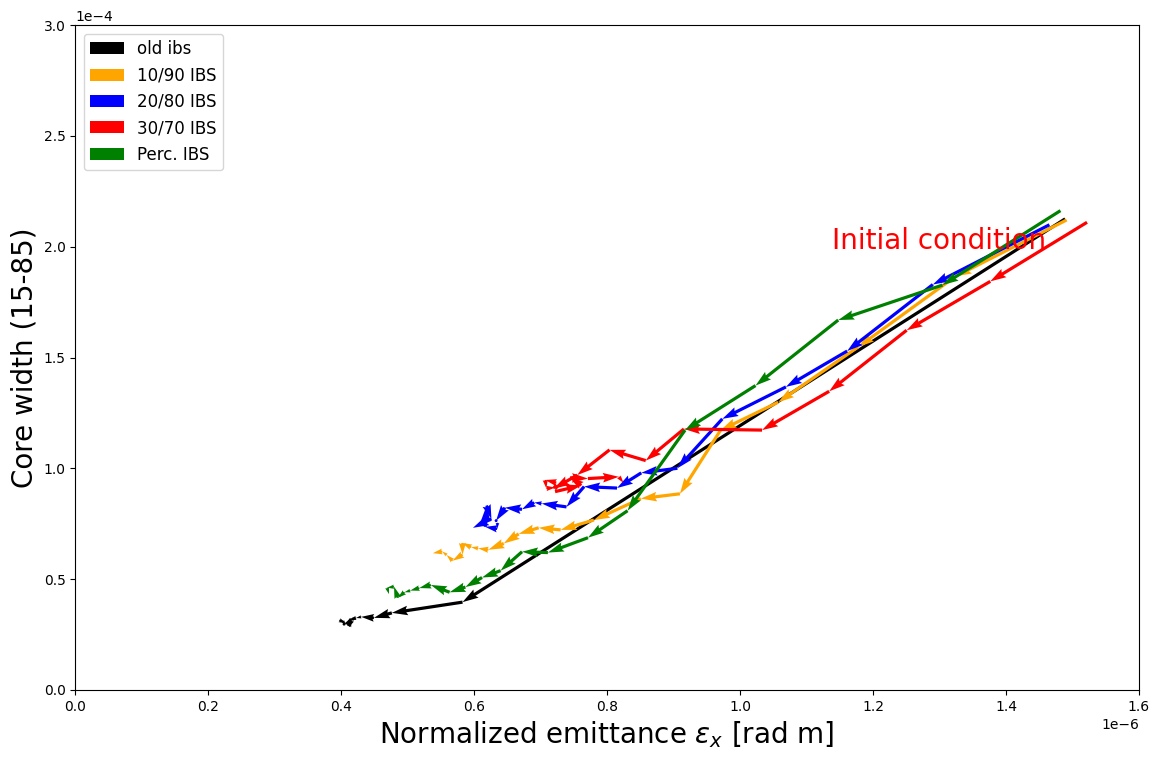

In [ ]:
plt.figure(figsize=(12, 8))
plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'black', label='old ibs')
# plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 
plot_quiver(emittance_x_10_90, core_width_10_90, time_10_90, 'orange', label='10/90 IBS') 
plot_quiver(emittance_x_20_80, core_width_20_80, time_20_80, 'blue', label='20/80 IBS') 
plot_quiver(emittance_x_30_70, core_width_30_70, time_30_70, 'red', label='30/70 IBS') 

plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Perc. IBS') 


injection_nemitt = emittance_x[0]
injection_dp_p = rms_dp_p[0]

#plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([0, 1.6*1e-6])
plt.ylim([0, 3*1e-4])
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]', fontsize=20)
plt.ylabel('Core width (15-85)', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
#     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# ], loc='lower right')

plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

In [ ]:
idx_to_look_at  = -1

print(f"{time_full_ibs[idx_to_look_at]} -> {np.std(delta_full_ibs[idx_to_look_at])}")
print(f"{time_old_ibs[idx_to_look_at]} -> {np.std(delta_old_ibs[idx_to_look_at])}")
print(f"{time_custom[idx_to_look_at]} -> {np.std(delta_custom[idx_to_look_at])}")
print(f"{time_20_80[idx_to_look_at]} -> {np.std(delta_20_80[idx_to_look_at])}")

print('------------------------------------------------------------------------------------------------------')

print(f"{time_10_90[idx_to_look_at]} -> {np.std(delta_10_90[idx_to_look_at])}")
print(f"{time_20_80[idx_to_look_at]} -> {np.std(delta_20_80[idx_to_look_at])}")
print(f"{time_30_70[idx_to_look_at]} -> {np.std(delta_30_70[idx_to_look_at])}")

1.9865430620330866 -> 0.00015511030187011614
99.98600657951455 -> 0.00012470208702294516
1.9865430620330866 -> 0.0001611103105417588
19.98522216176 -> 0.00010128810869576888
------------------------------------------------------------------------------------------------------
19.98522216176 -> 0.00014470699666792344
19.98522216176 -> 0.00010128810869576888
19.98522216176 -> 9.30063658068861e-05


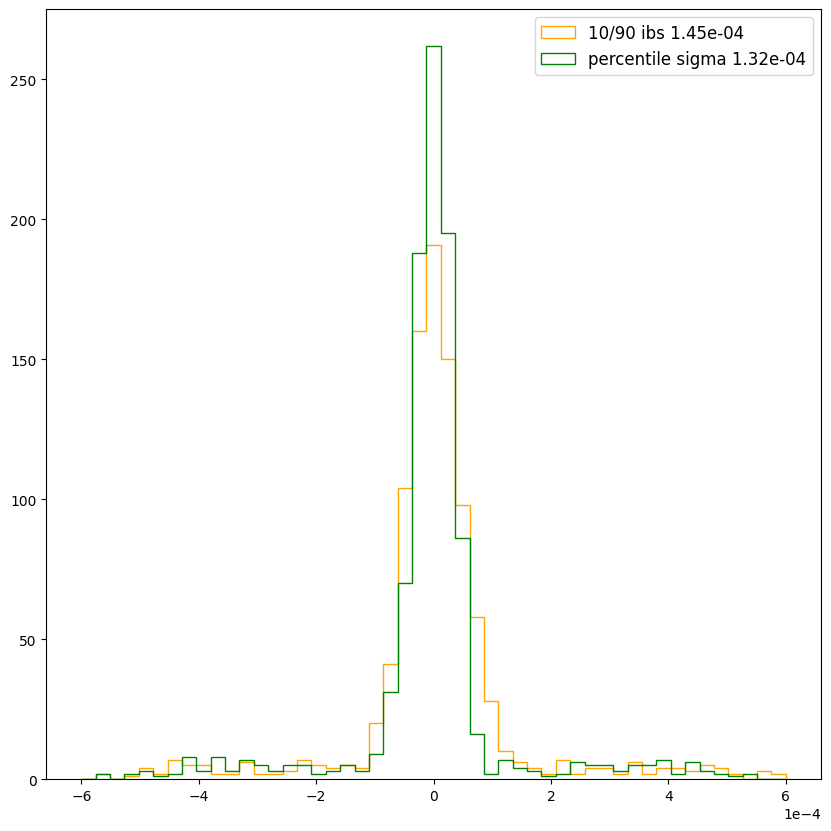

In [ ]:
idx_to_look_at = -1
bins=np.linspace(-6e-4,6e-4,50)
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')

#plt.hist(delta_no_ibs[idx_to_look_at],bins,histtype='step',color='yellow',density=False,label=f'no ibs {np.std(delta_no_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_old_ibs[idx_to_look_at],bins,histtype='step',color='black',density=False,label=f'old ibs {np.std(delta_old_ibs[idx_to_look_at]):.2e}')
plt.hist(delta_10_90[idx_to_look_at],bins,histtype='step',color='orange',density=False,label=f'10/90 ibs {np.std(delta_10_90[idx_to_look_at]):.2e}')
#plt.hist(delta_20_80[idx_to_look_at],bins,histtype='step',color='blue',density=False,label=f'20/80 ibs {np.std(delta_20_80[idx_to_look_at]):.2e}')
#plt.hist(delta_30_70[idx_to_look_at],bins,histtype='step',color='red',density=False,label=f'30/70 ibs {np.std(delta_30_70[idx_to_look_at]):.2e}')

plt.hist(delta_perc[idx_to_look_at],bins,histtype='step',color='green',density=False,label=f'percentile sigma {np.std(delta_perc[idx_to_look_at]):.2e}')


# plt.axvline(-np.std(delta_perc[idx_to_look_at]))
# plt.axvline(np.std(delta_perc[idx_to_look_at]))
#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import norm

# # Assume delta_perc is already defined and delta_perc_final is the last element.
# delta_perc_final = delta_perc[-1]

# rms=np.std(delta_perc_final)

# # Define the core using the 15th and 85th percentiles.
# p20, p80 = np.percentile(delta_perc_final, [15, 85])
# core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]
# core_width=(p80-p20)/2
# # Set up histogram bins.
# bins = np.linspace(-2e-4, 2e-4, 100)
# bins = np.linspace(min(delta_perc_final), max(delta_perc_final), 100)


# ####################################################################

# counts, bin_edges = np.histogram(delta_perc_final, bins=100, density=True)

# # Calculate bin centers.
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# # Find the maximum PDF value and corresponding x-value.
# max_pdf = counts.max()

# # Compute sigma from the formula σ = 1 / (sqrt(2π) * f_max)
# sigma = 1.0 / (np.sqrt(2.0 * np.pi) * max_pdf)

# print(f"f_max = {max_pdf}")
# print(f"sigma = {sigma:.4e}")

# # Plot histograms of the full dataset and the core.
# plt.figure(figsize=(10, 10))
# plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)

# # Fit a Gaussian to the core data.
# mu, std = norm.fit(delta_perc_final)

# # Generate x values for the fitted Gaussian curve.
# xmin, xmax = plt.xlim()
# x = np.linspace(xmin, xmax, 100)
# p = norm.pdf(x, mu, std)

# # Plot the fitted Gaussian curve.
# plt.plot(x, p, 'k', linewidth=2)
# plt.xlabel('Delta Percentage')
# plt.ylabel('Probability Density')

# plt.title('Histogram and Gaussian Fit')
# plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# plt.axvline(-std,label='gaussian sigma')
# plt.axvline(std)

# plt.axvline(-core_width,color='red',label='core width')
# plt.axvline(core_width,color='red')

# plt.axvline(-rms,color='orange',label='rms')
# plt.axvline(rms,color='orange')

# plt.axvline(-sigma,color='green',label='sigma max pdf')
# plt.axvline(sigma,color='green')

# plt.legend()
# plt.show()


In [ ]:
data = delta_peak[-1]

med = np.median(data)
mad = np.median(np.abs(data - med))
print(med)
print(mad)

1.5140004692160147e-06
2.4429781876667e-05


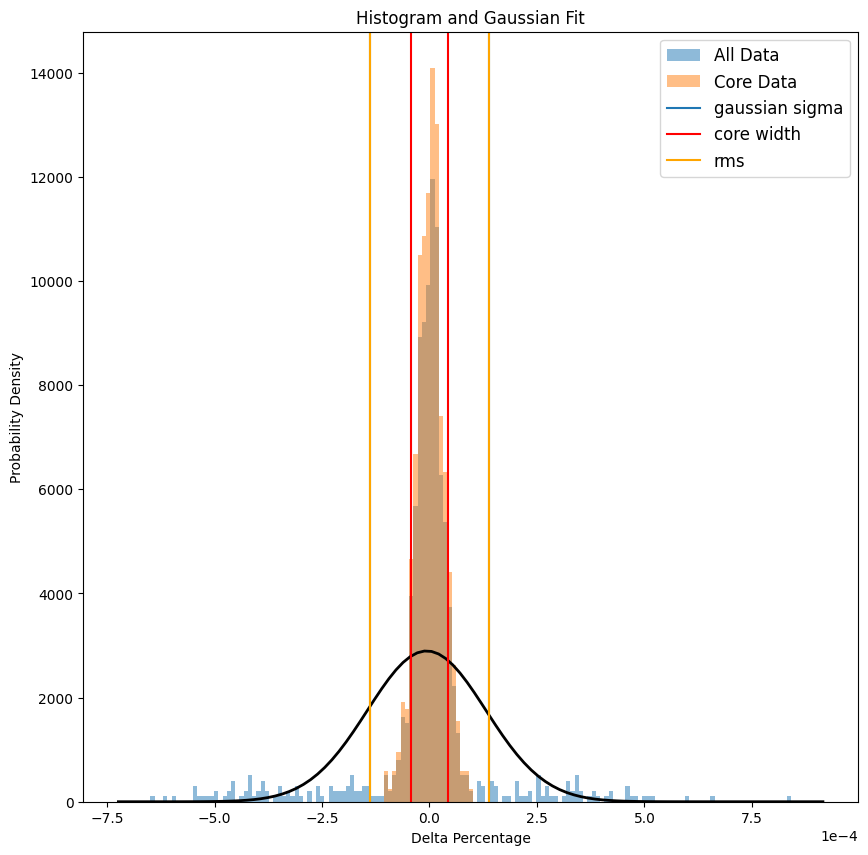

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assume delta_perc is already defined and delta_perc_final is the last element.
delta_perc_final = delta_old_ibs[-1]
delta_perc_final = delta_peak[-1]

rms=np.std(delta_perc_final)

# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]
core_width=(p80-p20)/2
# Set up histogram bins.

nbins=freedman_diaconis_bins(delta_perc_final)

bins = np.linspace(-2e-4, 2e-4, nbins)
bins = np.linspace(min(delta_perc_final), max(delta_perc_final), nbins)

#core_threshhold=extract_core_pdf_threshold(delta_perc_final,threshold=10)
core_threshhold=extract_core_mad_fast(delta_perc_final, scale=3.0)

# Plot histograms of the full dataset and the core.
plt.figure(figsize=(10, 10))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
# plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
plt.hist(core_threshhold, bins=bins, alpha=0.5, label='Core Data', density=True)

# Fit a Gaussian to the core data.
mu, std = norm.fit(delta_perc_final)

# Generate x values for the fitted Gaussian curve.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plot the fitted Gaussian curve.
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('Delta Percentage')
plt.ylabel('Probability Density')

plt.title('Histogram and Gaussian Fit')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.axvline(-std,label='gaussian sigma')
plt.axvline(std)

plt.axvline(-core_width,color='red',label='core width')
plt.axvline(core_width,color='red')

plt.axvline(-rms,color='orange',label='rms')
plt.axvline(rms,color='orange')

plt.legend()
plt.show()


custom ibs 2

In [ ]:
data_output= np.load(f'results/IBS_custom/{ion_loop.name}_output.npz')

delta_output = data_output['delta']
emittance_x_output = data_output['emittance_x']
time_output = data_output['time']
rms_dp_p_output = np.std(delta_output, axis=1)


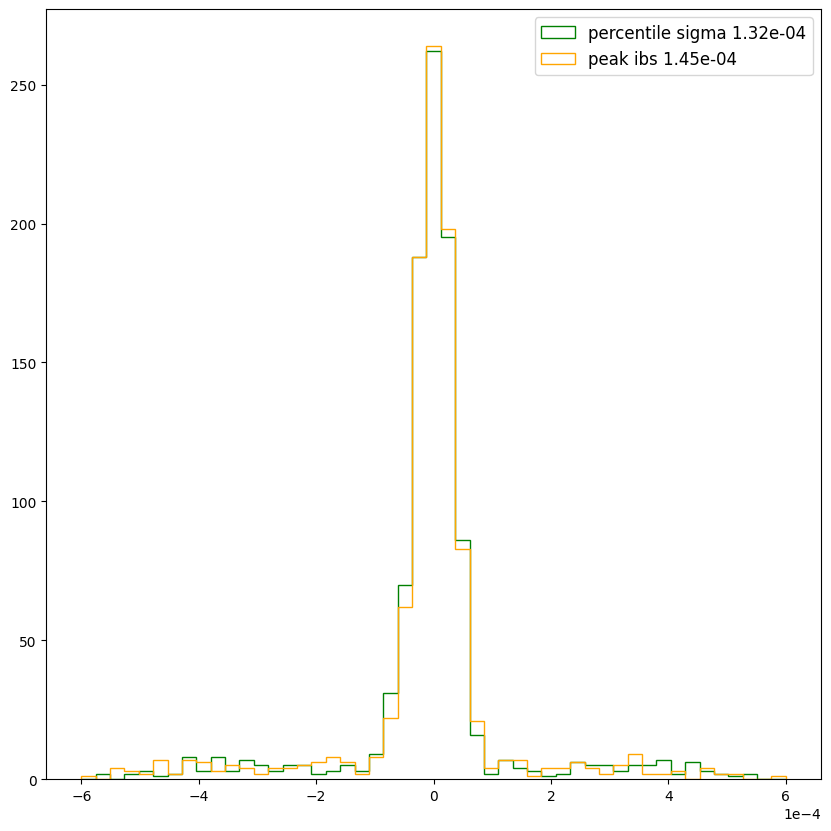

In [ ]:
idx_to_look_at = -1
bins=np.linspace(-6e-4,6e-4,50)
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')

#plt.hist(delta_no_ibs[idx_to_look_at],bins,histtype='step',color='yellow',density=False,label=f'no ibs {np.std(delta_no_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_old_ibs[idx_to_look_at],bins,histtype='step',color='black',density=False,label=f'old ibs {np.std(delta_old_ibs[idx_to_look_at]):.2e}')
#plt.hist(delta_20_80[idx_to_look_at],bins,histtype='step',color='blue',density=False,label=f'20/80 ibs {np.std(delta_20_80[idx_to_look_at]):.2e}')
#plt.hist(delta_30_70[idx_to_look_at],bins,histtype='step',color='red',density=False,label=f'30/70 ibs {np.std(delta_30_70[idx_to_look_at]):.2e}')

plt.hist(delta_perc[idx_to_look_at],bins,histtype='step',color='green',density=False,label=f'percentile sigma {np.std(delta_perc[idx_to_look_at]):.2e}')

plt.hist(delta_peak[idx_to_look_at],bins,histtype='step',color='orange',density=False,label=f'peak ibs {np.std(delta_10_90[idx_to_look_at]):.2e}')

#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()



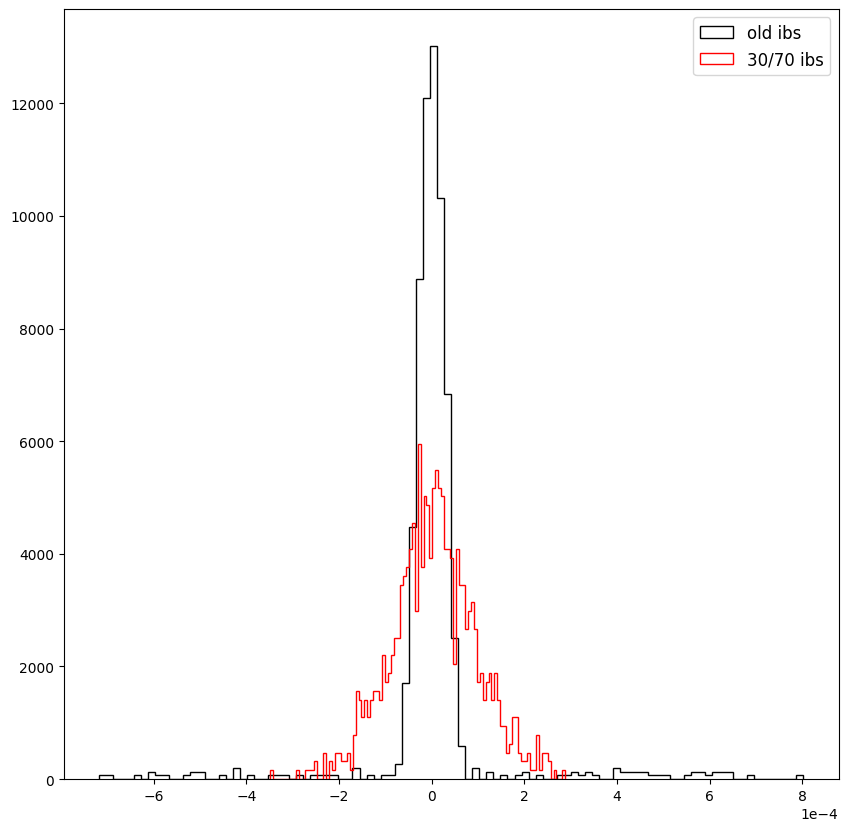

In [ ]:
plt.figure(figsize=(10,10))
# plt.hist(delta_full_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma full ibs')
# plt.hist(delta_old_ibs[idx_to_look_at], 100,histtype='step',density=True,label='sigma old ibs')
# plt.hist(delta_custom[idx_to_look_at],100,histtype='step',density=True,label='sigma only long. ibs')
plt.hist(delta_old_ibs[idx_to_look_at],100,histtype='step',color='black',density=True,label='old ibs')
# plt.hist(delta_10_90[idx_to_look_at],100,histtype='step',color='orange',density=True,label='10/90 ibs')
# plt.hist(delta_20_80[idx_to_look_at],100,histtype='step',color='blue',density=True,label='20/80 ibs')
plt.hist(delta_30_70[idx_to_look_at],100,histtype='step',color='red',density=True,label='30/70 ibs')
#plt.xlim([-0.00025,0.00025])
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()

with borders

In [ ]:
# from tqdm import tqdm
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D

# plt.figure(figsize=(12, 8))
# plt.rcParams.update({'font.size': 20})

# cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# for i, ion_loop in tqdm(enumerate([calcium])):    
    
#     data_custom = np.load(f'results/IBS_custom/{ion_loop.name}_new_kicks.npz')

#     delta_custom = data_custom['delta']
#     emittance_x_custom = data_custom['emittance_x']
#     time_custom = data_custom['time']
#     rms_dp_p_custom = np.std(delta_custom, axis=1)
    

#     # data_old_ibs = np.load(f'results/IBS/{ion_loop.name}.npz')

#     # delta_old_ibs = data_old_ibs['delta']
#     # emittance_x_old_ibs = data_old_ibs['emittance_x']
#     # time_old_ibs = data_old_ibs['time']
#     # rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)
#     # sigma_list_old_ibs=gauss_sigma(data_old_ibs)    

#     data_old_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_long.npz')

#     delta_old_ibs = data_old_ibs['delta']
#     emittance_x_old_ibs = data_old_ibs['emittance_x']
#     time_old_ibs = data_old_ibs['time']
#     rms_dp_p_old_ibs = np.std(delta_old_ibs, axis=1)

  
#     data_full_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_ibs_full.npz')

#     delta_full_ibs = data_full_ibs['delta']
#     emittance_x_full_ibs = data_full_ibs['emittance_x']
#     time_full_ibs = data_full_ibs['time']
#     rms_dp_p_full_ibs = np.std(delta_full_ibs, axis=1)
    

#     data_no_ibs = np.load(f'results/IBS_custom/{ion_loop.name}_no_ibs.npz')

#     delta_no_ibs = data_no_ibs['delta']
#     emittance_x_no_ibs = data_no_ibs['emittance_x']
#     time_no_ibs = data_no_ibs['time']
#     rms_dp_p_no_ibs = np.std(delta_no_ibs, axis=1)
    

#     # data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

#     # delta_10_90 = data_10_90['delta']
#     # emittance_x_10_90 = data_10_90['emittance_x']
#     # time_10_90 = data_10_90['time']
#     # rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
#     # sigma_list_10_90=gauss_sigma(data_10_90)

    

#     data_10_90 = np.load(f'results/IBS_custom/{ion_loop.name}_10_90.npz')

#     delta_10_90 = data_10_90['delta']
#     emittance_x_10_90 = data_10_90['emittance_x']
    
#     time_10_90 = data_10_90['time']
#     rms_dp_p_10_90 = np.std(delta_10_90, axis=1)
    

#     data_20_80 = np.load(f'results/IBS_custom/{ion_loop.name}_20_80.npz')

#     delta_20_80 = data_20_80['delta']
#     emittance_x_20_80 = data_20_80['emittance_x']
#     time_20_80 = data_20_80['time']
#     rms_dp_p_20_80 = np.std(delta_20_80, axis=1)
    

#     data_30_70 = np.load(f'results/IBS_custom/{ion_loop.name}_30_70.npz')

#     delta_30_70 = data_30_70['delta']
#     emittance_x_30_70 = data_30_70['emittance_x']
#     time_30_70 = data_30_70['time']
#     rms_dp_p_30_70 = np.std(delta_30_70, axis=1)
    




#     emittance_x_values = emittance_x_custom[:]
#     rms_dp_p_values = rms_dp_p_custom[:]   
    
# # plot_quiver(emittance_x_custom, sigma_list_custom, time_custom, 'orange', label='sigma only long. ibs')
# # plot_quiver(emittance_x_old_ibs, sigma_list_old_ibs, time_old_ibs, 'blue', label='sigma old ibs')
# # plot_quiver(emittance_x_full_ibs, sigma_list_full_ibs, time_full_ibs, 'red', label='sigma full ibs')     
  
# # plot_quiver(emittance_x_custom, rms_dp_p_custom, time_custom, 'black', label='only long. gaussian ibs')

# # plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs')

# # plot_quiver(emittance_x_old_ibs, rms_dp_p_old_ibs, time_old_ibs, 'black', label='old ibs')
# # plot_quiver(emittance_x_10_90, rms_dp_p_10_90, time_10_90, 'orange', label='10/90 IBS') 
# # plot_quiver(emittance_x_20_80, rms_dp_p_20_80, time_20_80, 'blue', label='20/80 IBS') 
# # plot_quiver(emittance_x_30_70, rms_dp_p_30_70, time_30_70, 'red', label='30/70 IBS') 


# plot_quiver(emittance_x_old_ibs, core_width_old_ibs, time_old_ibs, 'black', label='old ibs')
# # plot_quiver(emittance_x_full_ibs, rms_dp_p_full_ibs, time_full_ibs, 'blue', label='full gaussian ibs') 
# plot_quiver(emittance_x_10_90, core_width_10_90, time_10_90, 'orange', label='10/90 IBS') 
# plot_quiver(emittance_x_20_80, core_width_20_80, time_20_80, 'blue', label='20/80 IBS') 
# plot_quiver(emittance_x_30_70, core_width_30_70, time_30_70, 'red', label='30/70 IBS')
# plot_quiver(emittance_x_perc, core_width_perc, time_perc, 'green', label='Perc. IBS') 
# plot_quiver(emittance_x_peak, core_width_peak, time_perc, 'purple', label='Peak IBS') 

# ###############################################################################################################
# data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

# growth_rates_2d_x = data['growth_rates_2d_x']
# growth_rates_2d_y = data['growth_rates_2d_y']
# growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
# #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
# # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
# # max_growth_rate=growth_rates_2d_x
# sig_delta_list = data['sig_delta_list']
# n_emitt_list = data['n_emitt_list']
# total_intensity = data['total_intensity']

# loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
# transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
# longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
# #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
# laser_x_list = loaded_data['laser_x_list']

# min_transverse_index = np.argmin(transverse_growth_rate_list)
# min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)

# laser_position_index = min_transverse_index
# laser_offset = laser_x_list[laser_position_index]
# threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]
# threshold_transverse = -min(transverse_growth_rate_list)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
#             colors=cycle[0], linewidths=2)

# plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
#             colors=cycle[0], linestyles='--', linewidths=2)



# injection_nemitt = emittance_x[0]
# injection_dp_p = rms_dp_p[0]

# #plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
# plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

# # plt.xlim([0, 1.6*1e-6])
# # plt.ylim([0, 3*1e-4])
# plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]', fontsize=20)
# plt.ylabel('RMS dp/p', fontsize=20)
# plt.ylabel('Core width', fontsize=20)
# plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# # plt.legend(handles=[
# #     Line2D([0], [0], linestyle='-', color='black',  label='rms dp_p'),
# #     Line2D([0], [0], linestyle='--', color='orange', label='gaus sigma'),
          
# # ], loc='lower right')

# plt.legend(loc='upper left')

# plt.tight_layout()
# #plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
# plt.show()

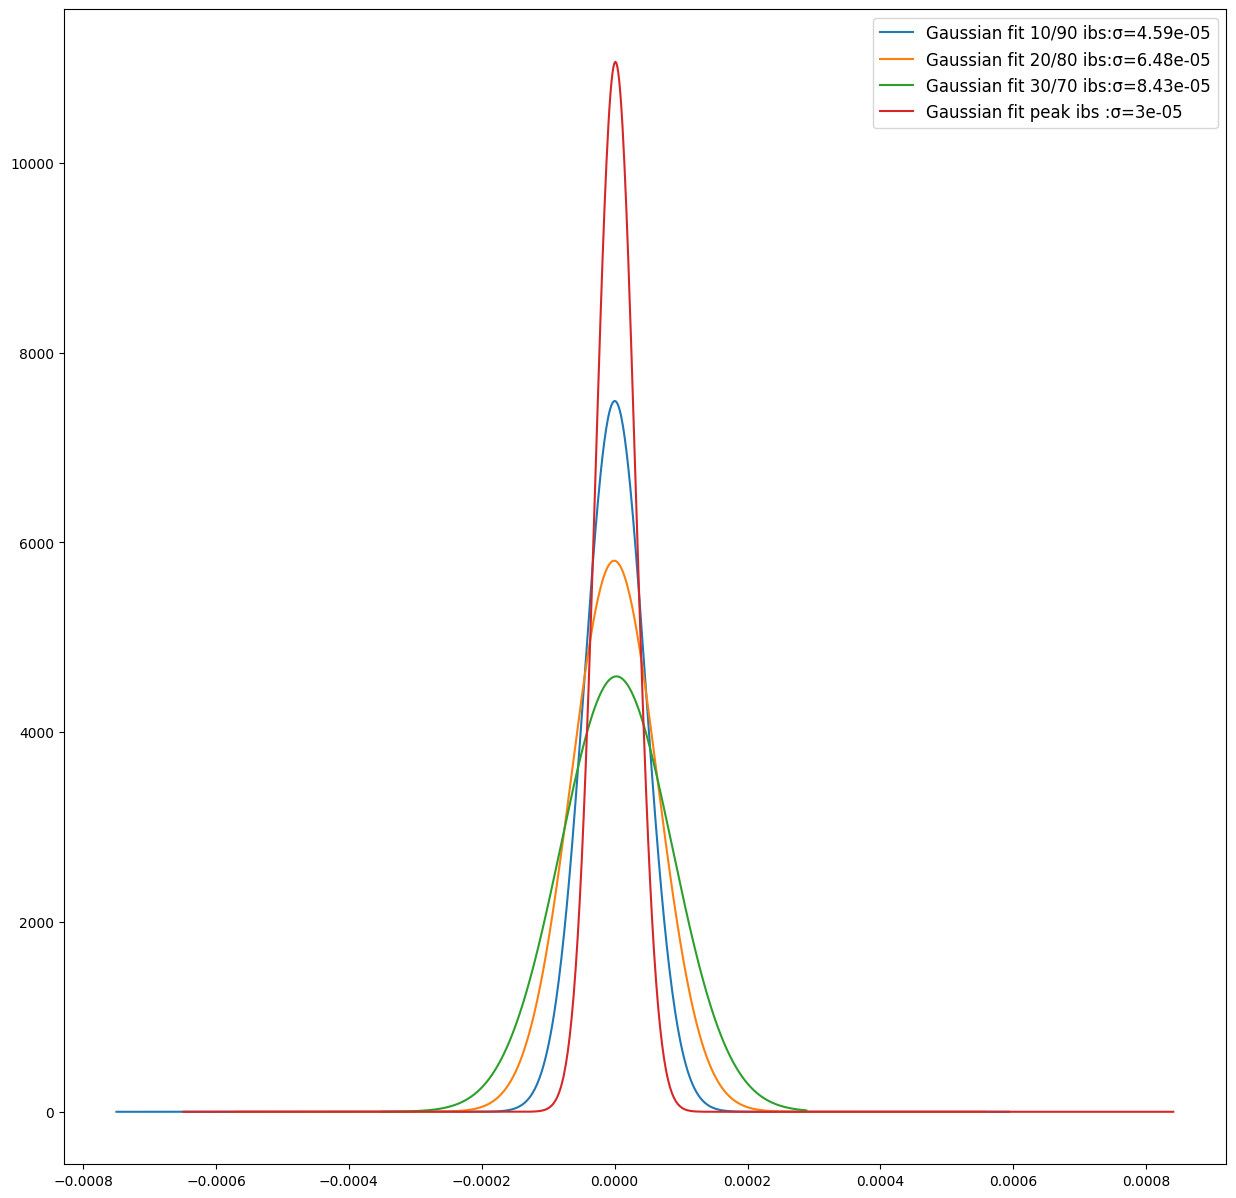

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the Gaussian function.
def gaussian(x, mu, sigma, amplitude):
    return amplitude * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Create a dictionary for your datasets.
datasets = {
    '10/90 ibs': delta_10_90[idx_to_look_at],
    '20/80 ibs': delta_20_80[idx_to_look_at],
    '30/70 ibs': delta_30_70[idx_to_look_at],
    'peak ibs ': delta_peak[idx_to_look_at],
}

plt.figure(figsize=(15, 15))

for label, data in datasets.items():
    # Compute the histogram without plotting it.
    counts, bins = np.histogram(data, bins=100, density=True)
    
    # Compute the bin centers from the bin edges.
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Initial parameter guesses: mean, standard deviation, and amplitude.
    mu_init = np.mean(data)
    sigma_init = np.std(data)
    amplitude_init = np.max(counts)
    
    # Fit the Gaussian function to the histogram data.
    popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[mu_init, sigma_init, amplitude_init])
    mu_fit, sigma_fit, amplitude_fit = popt
    
    # Generate x values for the fitted curve.
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    y_fit = gaussian(x_fit, mu_fit, sigma_fit, amplitude_fit)
    
    # Plot the Gaussian fit.
    plt.plot(x_fit, y_fit, label=f'Gaussian fit {label}:σ={sigma_fit:.3g}')

plt.legend()
plt.show()


ghetto gradient

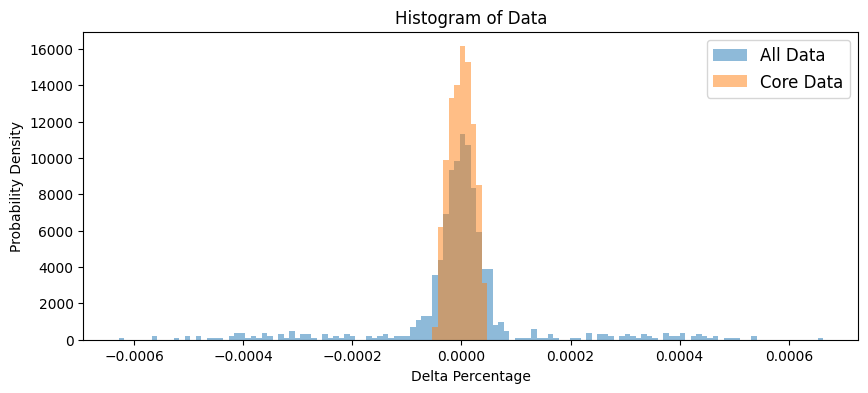

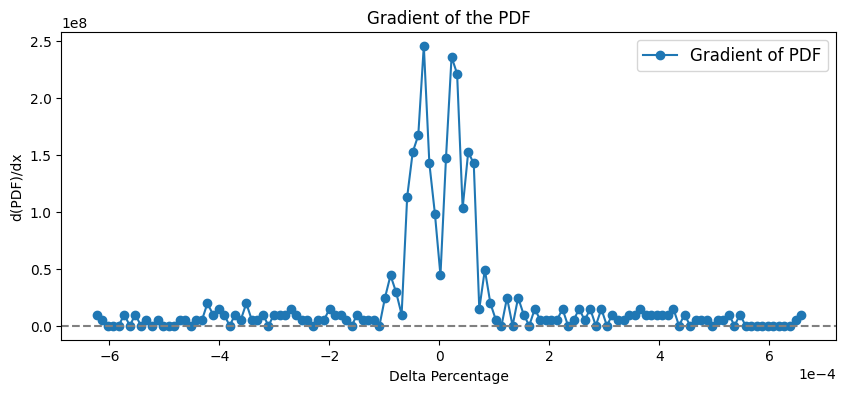

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Assume delta_perc is already defined; use its last element
delta_perc_final = delta_perc[-1]

n_bins=freedman_diaconis_bins(delta_perc_final)


# Define the core using the 15th and 85th percentiles.
p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]

# Set up histogram bins based on the range of delta_perc_final.
bins = np.linspace(np.min(delta_perc_final), np.max(delta_perc_final), n_bins)

# Plot the histograms for visualization
plt.figure(figsize=(10, 4))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
plt.hist(core, bins=bins, alpha=0.5, label='Core Data', density=True)
plt.xlabel('Delta Percentage')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Histogram of Data')
plt.show()

# Compute the PDF of delta_perc_final using a histogram.
# Use density=True so that the histogram approximates a PDF.
pdf_counts, bin_edges = np.histogram(delta_perc_final, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate the numerical gradient of the PDF.
dx = bin_centers[1] - bin_centers[0]  # uniform spacing
pdf_gradient = np.gradient(pdf_counts, dx)

max_grad=np.max(np.abs(pdf_gradient))

# Plot the gradient of the PDF.
plt.figure(figsize=(10, 4))
plt.plot(bin_centers, np.abs(pdf_gradient), marker='o', label='Gradient of PDF')
plt.xlabel('Delta Percentage')
plt.ylabel('d(PDF)/dx')
plt.title('Gradient of the PDF')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
# plt.yscale("log")
# plt.axhline(max_grad/100)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()


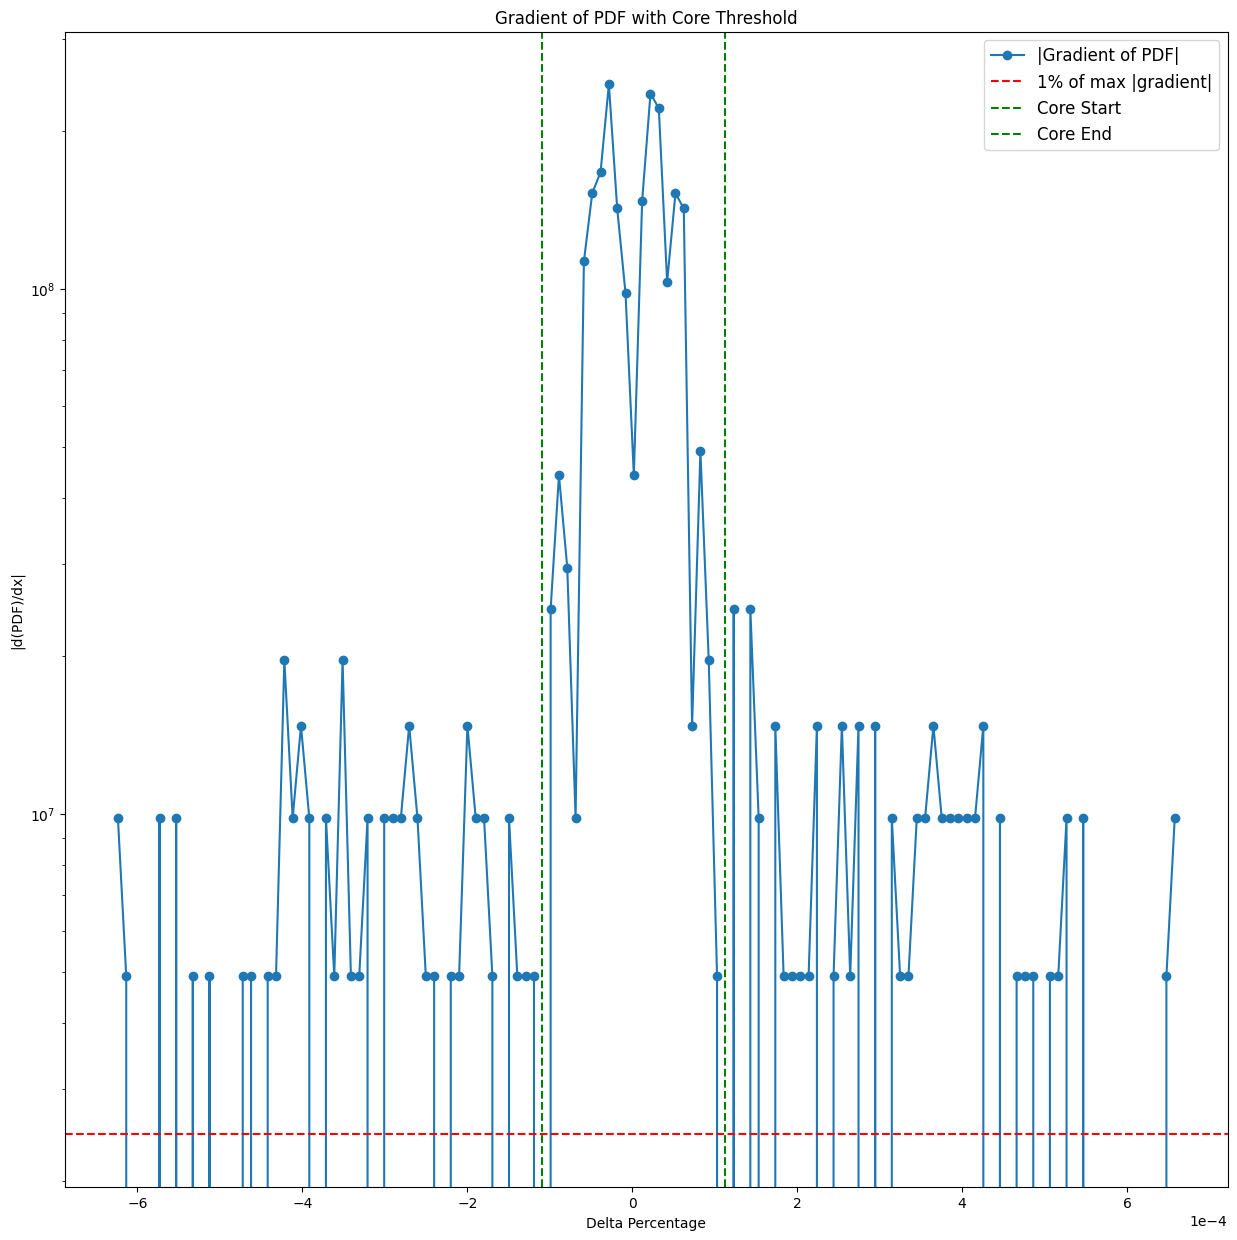

Core region: -1.09e-04 to 1.13e-04
Core points: 859, Tail points: 141


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume delta_perc, freedman_diaconis_bins are defined
delta_perc_final = delta_perc[-1]
n_bins = freedman_diaconis_bins(delta_perc_final)

# Histogram + PDF
bins = np.linspace(np.min(delta_perc_final), np.max(delta_perc_final), n_bins)
pdf_counts, bin_edges = np.histogram(delta_perc_final, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
dx = bin_centers[1] - bin_centers[0]
pdf_gradient = np.gradient(pdf_counts, dx)
abs_grad = np.abs(pdf_gradient)
max_grad = np.max(abs_grad)

# Threshold for core (1% of max gradient)
threshold = max_grad / 100

# Find core bounds based on where gradient falls below threshold
peak_index = np.argmax(pdf_counts)

# Scan left
left_index = peak_index
while left_index > 0 and abs_grad[left_index] > threshold:
    left_index -= 1

# Scan right
right_index = peak_index
while right_index < len(abs_grad) - 1 and abs_grad[right_index] > threshold:
    right_index += 1

# Core bounds in terms of x-values
core_left = bin_centers[left_index]
core_right = bin_centers[right_index]

# Separate core and tail data
core_data = delta_perc_final[(delta_perc_final >= core_left) & (delta_perc_final <= core_right)]
tail_data = delta_perc_final[(delta_perc_final < core_left) | (delta_perc_final > core_right)]

# ---- Plotting ----

# Gradient Plot (Log Scale)
plt.figure(figsize=(15,15))
plt.plot(bin_centers, abs_grad, marker='o', label='|Gradient of PDF|')
plt.axhline(threshold, color='red', linestyle='--', label='1% of max |gradient|')
plt.axvline(core_left, color='green', linestyle='--', label='Core Start')
plt.axvline(core_right, color='green', linestyle='--', label='Core End')
plt.xlabel('Delta Percentage')
plt.ylabel('|d(PDF)/dx|')
plt.yscale('log')
plt.title('Gradient of PDF with Core Threshold')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.show()

# Print results
print(f"Core region: {core_left:.2e} to {core_right:.2e}")
print(f"Core points: {len(core_data)}, Tail points: {len(tail_data)}")


In [ ]:
def freedman_diaconis_bins(data):
    """Determine optimal bin count using Freedman-Diaconis rule."""
    if len(data) < 2:
        return 1  # Avoid division errors
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = max(5, int((np.max(data) - np.min(data)) / bin_width))  # At least 5 bins
    return bins

def extract_core_from_gradient(data: np.ndarray, threshold_frac: float = 0.01) -> np.ndarray:
    
    n_bins = freedman_diaconis_bins(data)

    # Histogram and PDF
    bins = np.linspace(np.min(data), np.max(data), n_bins)
    pdf_counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    dx = bin_centers[1] - bin_centers[0]

    # Compute gradient of PDF
    pdf_gradient = np.gradient(pdf_counts, dx)
    abs_grad = np.abs(pdf_gradient)
    max_grad = np.max(abs_grad)
    threshold = max_grad * threshold_frac

    # Find peak of PDF
    peak_index = np.argmax(pdf_counts)

    # Find left bound
    left_index = peak_index
    while left_index > 0 and abs_grad[left_index] > threshold:
        left_index -= 1

    # Find right bound
    right_index = peak_index
    while right_index < len(abs_grad) - 1 and abs_grad[right_index] > threshold:
        right_index += 1

    core_left = bin_centers[left_index]
    core_right = bin_centers[right_index]

    # Extract core data
    core_data = data[(data >= core_left) & (data <= core_right)]

    return core_data

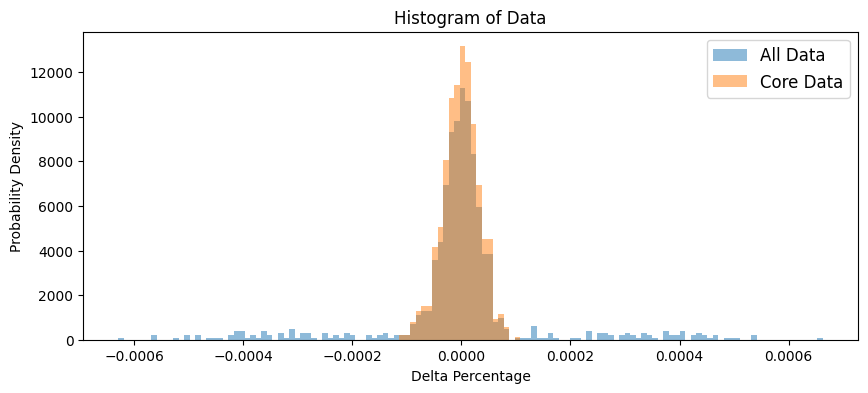

In [ ]:
# Plot the histograms for visualization
plt.figure(figsize=(10, 4))
plt.hist(delta_perc_final, bins=bins, alpha=0.5, label='All Data', density=True)
plt.hist(extract_core_from_gradient(delta_perc_final,threshold_frac=0.00001), bins=bins, alpha=0.5, label='Core Data', density=True)
plt.xlabel('Delta Percentage')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Histogram of Data')
plt.show()

array([-3.74490131e-05, -1.36046635e-05,  8.71731445e-06, -2.35355211e-05,
       -5.06194407e-05, -5.18412040e-06,  7.07030773e-06, -4.09448343e-07,
       -6.03405910e-06, -1.70213398e-05,  2.49008526e-05,  5.02176970e-06,
       -1.49241378e-05,  2.86822828e-05,  3.13887221e-05,  2.08108091e-05,
       -1.00441692e-05,  1.80981436e-05,  2.05896799e-05, -2.56978116e-05,
        4.89682969e-05, -1.64354123e-05,  3.12162424e-05, -1.76518218e-05,
        6.59810884e-06, -6.80982957e-06, -2.96622883e-05, -1.36004698e-05,
       -2.11733441e-05, -8.95361207e-06, -6.64364221e-07,  4.57970538e-06,
        2.79349388e-06, -9.44841527e-05,  3.27073730e-05,  4.09570853e-05,
        1.65647005e-05,  3.95869486e-05, -6.86442779e-06,  1.72304656e-05,
        8.83119004e-07,  4.32179055e-06,  2.49674097e-05,  2.50110337e-06,
       -5.43211358e-06,  1.73255064e-05,  8.50874525e-05, -4.31358027e-05,
        2.09606284e-05,  1.14598352e-06, -7.02123040e-06,  2.71371596e-05,
        1.47677130e-05,  

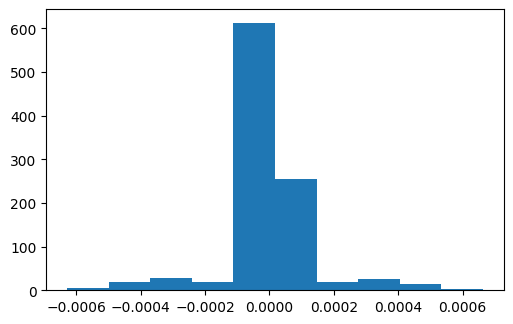

In [ ]:
data=delta_perc[-1]

plt.figure()
plt.hist(data)


extract_core_from_gradient(delta_perc[-1])

In [ ]:
x = 3 * sigma
decay = np.exp(-x**2 / (2 * sigma**2))
print(decay*100)

1.1108996538242317


In [ ]:
max(np.abs(pdf_gradient))

np.float64(245558656.69756356)

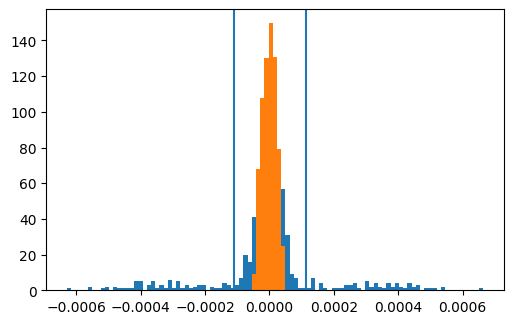

In [ ]:
delta_perc_final=delta_perc[-1]

p20, p80 = np.percentile(delta_perc_final, [15, 85])
core = delta_perc_final[(delta_perc_final >= p20) & (delta_perc_final <= p80)]



bins = np.linspace(min(delta_perc_final), max(delta_perc_final), 100)
plt.figure()

plt.hist(delta_perc_final,bins=bins)
plt.hist(core,bins=bins)
plt.axvline(core_left)
plt.axvline(core_right)

plt.show()

In [ ]:
import numpy as np

sigma = 1
x = 3 * sigma

# Gaussian PDF at x
pdf = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-x**2 / (2 * sigma**2))

# Derivative of the Gaussian PDF at x
pdf_derivative = (-x / sigma**2) * pdf

# Max of PDF is at x = 0
pdf_peak = 1 / (np.sqrt(2 * np.pi) * sigma)

# Express derivative magnitude as % of peak PDF
relative_grad = np.abs(pdf_derivative) / pdf_peak * 100

print(f"Gradient magnitude at x = 3σ: {relative_grad:.5f}% of PDF peak")


Gradient magnitude at x = 3σ: 3.33270% of PDF peak
